In [1]:
# ============================================================
# Cell 1: Top-level imports + module reload
# ============================================================

import re
import gc
import json
import time
import random
import hashlib
import importlib
from dataclasses import asdict, is_dataclass
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import torch
except ImportError:
    torch = None

import config
import metrics
import model_loader
import modes
import workloads
import benchmark_modes
import reporter
import controller
import controller.features as controller_features
import controller.classifier as controller_classifier
import controller.router as controller_router
import runner

for module in [
    config,
    metrics,
    model_loader,
    modes,
    workloads,
    controller_features,
    controller_classifier,
    controller_router,
    controller,
    runner,
    benchmark_modes,
    reporter,
]:
    importlib.reload(module)

from config import CONFIG, RAW_RESULTS_DIR, BENCHMARK_DATA_DIR
from modes import build_runtime_mode_by_name
from workloads import (
    build_runtime_workload_by_name,
    build_runtime_workloads_for_name,
)
from runner import run_single_benchmark
from benchmark_modes import (
    save_results_json,
    save_results_csv,
    save_summary_csv,
    build_aggregate_rows,
    build_comparison_rows,
    save_aggregate_csv,
    apply_external_score_sidecar,
    annotate_results_with_baseline_similarity,
)
from reporter import generate_full_report
from controller import classify_request, route_request, route_runtime_workload
from controller.features import RequestFeatures

print("Project root:", Path.cwd())
print("RAW_RESULTS_DIR:", RAW_RESULTS_DIR)
print("BENCHMARK_DATA_DIR:", BENCHMARK_DATA_DIR)

Project root: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM
RAW_RESULTS_DIR: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw
BENCHMARK_DATA_DIR: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/benchmark_data


In [2]:
# from pathlib import Path
# import json
# import pandas as pd

# RAW_RESULTS_DIR = Path("/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw")

# partials = sorted(
#     RAW_RESULTS_DIR.glob("dense_final_partial_*.json"),
#     key=lambda p: p.stat().st_mtime,
# )

# print("Found partial checkpoints:", len(partials))

# for p in partials[-10:]:
#     print(p, "size_MB=", round(p.stat().st_size / 1e6, 2))

In [3]:
# latest_partial = partials[-2]
# print("Latest partial:", latest_partial)

# with open(latest_partial, "r", encoding="utf-8") as f:
#     rows = json.load(f)

# print("Recovered rows:", len(rows))

# pd.DataFrame(rows)[["mode_name", "workload_name", "trial_index", "success"]].tail(20)

In [4]:
# ============================================================
# Cell 2: Notebook helpers
# ============================================================

def resolve_runtime_mode(mode_name: str):
    return build_runtime_mode_by_name(mode_name)


def resolve_runtime_workload(workload_name: str):
    return build_runtime_workload_by_name(workload_name)


def expand_workload_group_names(workload_group_names):
    expanded = []

    for workload_name in workload_group_names:
        if re.fullmatch(r"shared_prefix_chat_v\d+", workload_name):
            expanded.append(workload_name)
            continue

        runtime_rows = build_runtime_workloads_for_name(workload_name)
        expanded.extend([row.name for row in runtime_rows])

    return list(dict.fromkeys(expanded))


def canonical_workload_group_name(expanded_workload_name: str) -> str:
    if "__" in str(expanded_workload_name):
        return str(expanded_workload_name).split("__", 1)[0]
    return str(expanded_workload_name)


def run_one(mode_name: str, workload_name: str, trial_index: int = 0):
    runtime_mode = resolve_runtime_mode(mode_name)
    runtime_workload = resolve_runtime_workload(workload_name)

    return run_single_benchmark(
        runtime_mode=runtime_mode,
        workload=runtime_workload,
        trial_index=trial_index,
    )


def fmt_num(x, decimals=2):
    if x is None or pd.isna(x):
        return "NA"
    return f"{x:.{decimals}f}"


def count_jsonl_rows(path: Path) -> int:
    if not path.exists():
        return 0

    n = 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                n += 1

    return n


def preview_jsonl(path: Path, n=2):
    print("\nPreview:", path)

    if not path.exists():
        print("Missing file.")
        return

    with open(path, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f):
            if idx >= n:
                break
            print(line.strip())

In [5]:
# ============================================================
# Checkpoint / resume helpers
# ============================================================

def json_safe_value(value):
    """
    Convert common Python/numpy objects into JSON-safe values.
    """
    if isinstance(value, dict):
        return {str(k): json_safe_value(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe_value(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value


def result_to_plain_dict(result):
    """
    Convert a BenchmarkResult/dataclass/object/dict into a plain dict.
    """
    if isinstance(result, dict):
        raw = result
    elif is_dataclass(result):
        raw = asdict(result)
    elif hasattr(result, "__dict__"):
        raw = dict(vars(result))
    else:
        raise TypeError(f"Cannot serialize result of type {type(result)}")

    return json_safe_value(raw)


def load_json_rows(path):
    path = Path(path)
    if not path.exists():
        return []

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, list):
        return data
    if isinstance(data, dict) and "results" in data:
        return data["results"]

    raise ValueError(f"Unexpected JSON checkpoint format: {path}")


def find_latest_json_checkpoint(directory, patterns):
    candidates = []
    for pattern in patterns:
        candidates.extend(Path(directory).glob(pattern))

    candidates = [p for p in candidates if p.exists()]
    if not candidates:
        return None

    return sorted(candidates, key=lambda p: p.stat().st_mtime)[-1]


def run_key_from_row(row):
    """
    Key used to decide whether a run has already completed.
    """
    mode_name = row.get("mode_name")
    workload_name = row.get("workload_name")
    trial_index = row.get("trial_index")

    if mode_name is None or workload_name is None or trial_index is None:
        return None

    return (str(mode_name), str(workload_name), int(trial_index))


def dedupe_rows_by_run_key(rows):
    """
    Keep the latest row for each mode/workload/trial key.
    """
    keyed_rows = {}
    unkeyed_rows = []

    for row in rows:
        key = run_key_from_row(row)
        if key is None:
            unkeyed_rows.append(row)
        else:
            keyed_rows[key] = row

    return unkeyed_rows + list(keyed_rows.values())


def save_resume_checkpoint(existing_raw_rows, new_result_objects, json_path, csv_path):
    """
    Save existing checkpoint rows + new in-memory result objects.
    Uses atomic temp-file replacement so crashes do not corrupt the checkpoint.
    """
    new_raw_rows = [result_to_plain_dict(result) for result in new_result_objects]
    combined_rows = dedupe_rows_by_run_key(existing_raw_rows + new_raw_rows)

    json_path = Path(json_path)
    csv_path = Path(csv_path)

    json_path.parent.mkdir(parents=True, exist_ok=True)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    tmp_json_path = json_path.with_suffix(json_path.suffix + ".tmp")
    tmp_csv_path = csv_path.with_suffix(csv_path.suffix + ".tmp")

    with open(tmp_json_path, "w", encoding="utf-8") as f:
        json.dump(combined_rows, f, indent=2, ensure_ascii=False)

    pd.DataFrame(combined_rows).to_csv(tmp_csv_path, index=False)

    tmp_json_path.replace(json_path)
    tmp_csv_path.replace(csv_path)

    return combined_rows

In [6]:
# ============================================================
# Cell 3: Verify benchmark sidecars
# ============================================================

SIDECARE_FILES = {
    "mmlu_pro_eval": "mmlu_pro_eval.jsonl",
    "gsm8k_eval": "gsm8k_eval.jsonl",
    "truthfulqa_eval": "truthfulqa_eval.jsonl",
    "gpqa_eval": "gpqa_eval.jsonl",
    "mlu_eval": "mlu_eval.jsonl",
}

sidecar_rows = []

for group_name, filename in SIDECARE_FILES.items():
    path = BENCHMARK_DATA_DIR / filename
    sidecar_rows.append({
        "workload_group": group_name,
        "path": str(path),
        "exists": path.exists(),
        "rows": count_jsonl_rows(path),
    })

sidecar_df = pd.DataFrame(sidecar_rows)
display(sidecar_df)

missing = sidecar_df[~sidecar_df["exists"]]
if len(missing) > 0:
    raise FileNotFoundError("Missing sidecars:\n" + "\n".join(missing["path"].tolist()))

for group_name, filename in SIDECARE_FILES.items():
    preview_jsonl(BENCHMARK_DATA_DIR / filename, n=1)

,workload_group,path,exists,rows
0,mmlu_pro_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,1000
1,gsm8k_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,1000
2,truthfulqa_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,817
3,gpqa_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,546
4,mlu_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,1000



Preview: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/benchmark_data/mmlu_pro_eval.jsonl
{"id": "mmlu_pro_0001", "prompt": "Question: Which of the following was not cited as evidence for life in the martian meteorite ALH84001?\nA. Amino acids with a preferred orientation or \"chirality\"\nB. Magnetite grains similar to those formed by bacteria on Earth\nC. Methane traces within the meteorite\nD. High levels of sulfur, indicating a possible volcanic origin\nE. Detection of radio signals from the meteorite\nF. Carbonate minerals indicating a thicker warmer Martian atmosphere\nG. Presence of water-ice in the meteorite\nH. Presence of olivine, a common mineral in Martian meteorites\nI. Fossilized microbial life forms within the meteorite\nJ. Complex organic molecules specifically PAHs\nAnswer with the correct letter only.", "reference": "A", "valid_labels": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"], "benchmark_suite": "mmlu_pro", "benchmark_subset": "physics", "benchmark_langua

In [7]:
# ============================================================
# Cell 4: Final sweep configuration
# ============================================================
RUN_EXTERNAL_JUDGE_WORKLOADS = False

STANDARD_DENSE_MODES = [
    "fp16_baseline",
    "gptq_4bit",
    "int8_quant",
    "speculative_decoding",
    "gptq_plus_prefix_caching",
    "int8_plus_continuous_batching",
    "prefix_caching",
    "continuous_batching",
]

BENCHMARK_DENSE_MODES = [
    "fp16_baseline",
    "gptq_4bit",
    "int8_quant",
    "speculative_decoding",
    "prefix_caching",
]

NORMAL_WORKLOAD_GROUPS = {
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat_v0",
    "shared_prefix_chat_v1",
    "memory_pressure_long_context",
}

AUTOMATIC_ACCURACY_WORKLOAD_GROUPS = {
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
}

EXTERNAL_JUDGE_WORKLOAD_GROUPS = {
}

BENCHMARK_WORKLOAD_GROUPS = (
    AUTOMATIC_ACCURACY_WORKLOAD_GROUPS
)

FINAL_DENSE_WORKLOAD_GROUPS = [
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat",
    "memory_pressure_long_context",
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
]

# Normal fixed workloads get repeated trials.
NORMAL_NUM_TRIALS = 30 # Change to 15 or 20

# Benchmark-style workloads use many unique prompts and only one generation per prompt/mode.
BENCHMARK_NUM_TRIALS = 1

# Random prompt caps per benchmark group.
# MT-Bench only has 80, so use all 80.
WORKLOAD_SAMPLE_LIMITS = {
    "mmlu_pro_eval": 1000,
    "gsm8k_eval": 1000,
    "truthfulqa_eval": 800,
    "gpqa_eval": 500,
    "mlu_eval": 1000,
}

WORKLOAD_SAMPLE_SEED = 42

STANDARD_DENSE_MODES = list(dict.fromkeys(STANDARD_DENSE_MODES))
BENCHMARK_DENSE_MODES = list(dict.fromkeys(BENCHMARK_DENSE_MODES))
FINAL_DENSE_WORKLOAD_GROUPS = list(dict.fromkeys(FINAL_DENSE_WORKLOAD_GROUPS))

def trials_for_workload(expanded_workload_name: str) -> int:
    group_name = canonical_workload_group_name(expanded_workload_name)

    if group_name in BENCHMARK_WORKLOAD_GROUPS:
        return BENCHMARK_NUM_TRIALS

    return NORMAL_NUM_TRIALS


def modes_for_workload(expanded_workload_name: str):
    group_name = canonical_workload_group_name(expanded_workload_name)

    if group_name in BENCHMARK_WORKLOAD_GROUPS:
        return BENCHMARK_DENSE_MODES

    return STANDARD_DENSE_MODES


def sample_expanded_workloads_for_group(group_name: str):
    expanded = expand_workload_group_names([group_name])
    expanded = list(dict.fromkeys(expanded))

    limit = WORKLOAD_SAMPLE_LIMITS.get(group_name)

    if limit is None or len(expanded) <= limit:
        return expanded

    stable_digest = hashlib.md5(group_name.encode("utf-8")).hexdigest()
    stable_offset = int(stable_digest[:8], 16)
    rng = random.Random(WORKLOAD_SAMPLE_SEED + stable_offset)
    sampled = rng.sample(expanded, k=limit)

    return sorted(sampled)

In [8]:
# ============================================================
# Cell 5: Expand sampled final workload plan
# ============================================================

expanded_workloads = []

for group_name in FINAL_DENSE_WORKLOAD_GROUPS:
    expanded_workloads.extend(sample_expanded_workloads_for_group(group_name))

FINAL_DENSE_WORKLOADS = list(dict.fromkeys(expanded_workloads))

TOTAL_DENSE_RUNS = sum(
    len(modes_for_workload(workload_name)) * trials_for_workload(workload_name)
    for workload_name in FINAL_DENSE_WORKLOADS
)

plan_rows = []

for workload_name in FINAL_DENSE_WORKLOADS:
    group_name = canonical_workload_group_name(workload_name)

    for mode_name in modes_for_workload(workload_name):
        plan_rows.append({
            "mode_name": mode_name,
            "workload_name": workload_name,
            "workload_group": group_name,
            "trials": trials_for_workload(workload_name),
        })

plan_df = pd.DataFrame(plan_rows)

group_plan_df = (
    plan_df
    .groupby("workload_group", as_index=False)
    .agg(
        num_expanded_workloads=("workload_name", "nunique"),
        num_modes=("mode_name", "nunique"),
        trials_per_pair=("trials", "max"),
        planned_runs=("trials", "sum"),
    )
)

print("Standard dense modes:")
for mode_name in STANDARD_DENSE_MODES:
    print(" -", mode_name)

print("\nBenchmark-safe dense modes:")
for mode_name in BENCHMARK_DENSE_MODES:
    print(" -", mode_name)

print("\nTotal expanded workloads:", len(FINAL_DENSE_WORKLOADS))
print("Total planned runs:", TOTAL_DENSE_RUNS)

display(group_plan_df)
display(plan_df.head(30))
display(plan_df.tail(30))

Standard dense modes:
 - fp16_baseline
 - gptq_4bit
 - int8_quant
 - speculative_decoding
 - gptq_plus_prefix_caching
 - int8_plus_continuous_batching
 - prefix_caching
 - continuous_batching

Benchmark-safe dense modes:
 - fp16_baseline
 - gptq_4bit
 - int8_quant
 - speculative_decoding
 - prefix_caching

Total expanded workloads: 4324
Total planned runs: 27260


,workload_group,num_expanded_workloads,num_modes,trials_per_pair,planned_runs
0,gpqa_eval,500,5,1,2500
1,gsm8k_eval,1000,5,1,5000
2,long_prompt_long_output,1,8,30,240
3,long_prompt_short_output,1,8,30,240
4,memory_pressure_long_context_v0,1,8,30,240
5,memory_pressure_long_context_v1,1,8,30,240
6,memory_pressure_long_context_v2,1,8,30,240
7,memory_pressure_long_context_v3,1,8,30,240
8,memory_pressure_long_context_v4,1,8,30,240
9,memory_pressure_long_context_v5,1,8,30,240


,mode_name,workload_name,workload_group,trials
0,fp16_baseline,short_prompt_short_output,short_prompt_short_output,30
1,gptq_4bit,short_prompt_short_output,short_prompt_short_output,30
2,int8_quant,short_prompt_short_output,short_prompt_short_output,30
3,speculative_decoding,short_prompt_short_output,short_prompt_short_output,30
4,gptq_plus_prefix_caching,short_prompt_short_output,short_prompt_short_output,30
5,int8_plus_continuous_batching,short_prompt_short_output,short_prompt_short_output,30
6,prefix_caching,short_prompt_short_output,short_prompt_short_output,30
7,continuous_batching,short_prompt_short_output,short_prompt_short_output,30
8,fp16_baseline,short_prompt_long_output,short_prompt_long_output,30
9,gptq_4bit,short_prompt_long_output,short_prompt_long_output,30


,mode_name,workload_name,workload_group,trials
21662,fp16_baseline,mlu_eval__mlu_0995,mlu_eval,1
21663,gptq_4bit,mlu_eval__mlu_0995,mlu_eval,1
21664,int8_quant,mlu_eval__mlu_0995,mlu_eval,1
21665,speculative_decoding,mlu_eval__mlu_0995,mlu_eval,1
21666,prefix_caching,mlu_eval__mlu_0995,mlu_eval,1
21667,fp16_baseline,mlu_eval__mlu_0996,mlu_eval,1
21668,gptq_4bit,mlu_eval__mlu_0996,mlu_eval,1
21669,int8_quant,mlu_eval__mlu_0996,mlu_eval,1
21670,speculative_decoding,mlu_eval__mlu_0996,mlu_eval,1
21671,prefix_caching,mlu_eval__mlu_0996,mlu_eval,1


In [9]:
# ============================================================
# Cell 6: Resolve and inspect final mode set
# ============================================================

ALL_FINAL_DENSE_MODES = list(dict.fromkeys(STANDARD_DENSE_MODES + BENCHMARK_DENSE_MODES))

resolved_dense_rows = []

for mode_name in ALL_FINAL_DENSE_MODES:
    mode = resolve_runtime_mode(mode_name)
    resolved_dense_rows.append({
        "mode_name": mode.name,
        "backend": mode.backend,
        "quantization": mode.quantization,
        "prefix_caching": mode.prefix_caching,
        "continuous_batching": mode.continuous_batching,
        "speculative_decoding": mode.speculative_decoding,
        "primary_phase": mode.primary_phase,
        "notes": mode.notes,
    })

resolved_dense_df = pd.DataFrame(resolved_dense_rows)
display(resolved_dense_df)

,mode_name,backend,quantization,prefix_caching,continuous_batching,speculative_decoding,primary_phase,notes
0,fp16_baseline,vllm,None,False,False,False,both,standard mode
1,gptq_4bit,vllm,gptq,False,False,False,decode,quantization=gptq
2,int8_quant,vllm,compressed-tensors,False,False,False,decode,quantization=compressed-tensors
3,speculative_decoding,vllm,None,False,False,True,decode,speculative decoding enabled
4,gptq_plus_prefix_caching,vllm,gptq,True,False,False,both,quantization=gptq; prefix caching enabled
5,int8_plus_continuous_batching,vllm,compressed-tensors,False,True,False,decode,quantization=compressed-tensors; continuous ba...
6,prefix_caching,vllm,None,True,False,False,prefill,prefix caching enabled
7,continuous_batching,vllm,None,False,True,False,decode,continuous batching benchmark uses a multi-req...


In [10]:
# ============================================================
# Cell 7: Execute final sweep (reuse loaded bundle per mode)
# ============================================================

from model_loader import load_model_for_mode, unload_model

dense_results = []
dense_error_rows = []

dense_run_stamp = time.strftime("%Y%m%d_%H%M%S")
dense_partial_json_path = RAW_RESULTS_DIR / f"dense_final_partial_{dense_run_stamp}.json"
dense_partial_csv_path = RAW_RESULTS_DIR / f"dense_final_partial_{dense_run_stamp}.csv"

RESUME_DENSE_SWEEP = True
DENSE_RESUME_JSON_PATH = None

dense_existing_raw_rows = []
dense_completed_keys = set()

if RESUME_DENSE_SWEEP:
    if DENSE_RESUME_JSON_PATH is None:
        DENSE_RESUME_JSON_PATH = find_latest_json_checkpoint(
            RAW_RESULTS_DIR,
            patterns=[
                "dense_final_partial_*.json",
                "dense_final_prejudge_results_*.json",
                "dense_final_results_*.json",
            ],
        )

    if DENSE_RESUME_JSON_PATH is not None:
        dense_existing_raw_rows = load_json_rows(DENSE_RESUME_JSON_PATH)
        dense_completed_keys = {
            key
            for key in (run_key_from_row(row) for row in dense_existing_raw_rows)
            if key is not None
        }

        print("Resuming dense sweep from:", DENSE_RESUME_JSON_PATH)
        print("Previously completed dense runs:", len(dense_completed_keys))
    else:
        print("No dense checkpoint found. Starting dense sweep from scratch.")

run_counter = len(dense_completed_keys)

# Build the full expected run plan, then keep ONLY missing rows.
expected_run_rows = []

for workload_name in FINAL_DENSE_WORKLOADS:
    for mode_name in modes_for_workload(workload_name):
        for trial_index in range(trials_for_workload(workload_name)):
            expected_run_rows.append({
                "mode_name": mode_name,
                "workload_name": workload_name,
                "trial_index": trial_index,
            })

expected_run_df = pd.DataFrame(expected_run_rows)

missing_run_df = expected_run_df[
    ~expected_run_df.apply(
        lambda r: (
            str(r["mode_name"]),
            str(r["workload_name"]),
            int(r["trial_index"]),
        ) in dense_completed_keys,
        axis=1,
    )
].reset_index(drop=True)

print("Expected total runs:", len(expected_run_df))
print("Completed runs in checkpoint:", len(dense_completed_keys))
print("Missing runs to execute now:", len(missing_run_df))
display(missing_run_df)

MAX_ALLOWED_MISSING_RUNS = 3000

if len(missing_run_df) > MAX_ALLOWED_MISSING_RUNS:
    raise RuntimeError(
        f"Refusing to continue because {len(missing_run_df)} runs are missing. "
        f"This is above MAX_ALLOWED_MISSING_RUNS={MAX_ALLOWED_MISSING_RUNS}. "
        "Inspect missing_run_df before continuing."
    )

# Build per-mode workload list using ONLY missing rows so we do not load every mode again.
mode_to_workloads = {}
for mode_name in ALL_FINAL_DENSE_MODES:
    if len(missing_run_df) == 0:
        mode_to_workloads[mode_name] = []
    else:
        mode_to_workloads[mode_name] = (
            missing_run_df[missing_run_df["mode_name"] == mode_name]["workload_name"]
            .drop_duplicates()
            .tolist()
        )

try:
    for mode_name in ALL_FINAL_DENSE_MODES:
        runtime_mode = resolve_runtime_mode(mode_name)
        relevant_workloads = mode_to_workloads[mode_name]
        if len(relevant_workloads) == 0:
            print(f"Skipping mode with no missing runs: {mode_name}")
            continue
            
        print("\n" + "#" * 120)
        print(f"LOADING MODE ONCE: {mode_name}")
        print(f"Missing workloads for this mode: {len(relevant_workloads)}")
        print("#" * 120)

        bundle = None

        try:
            bundle = load_model_for_mode(runtime_mode)

            for workload_name in relevant_workloads:
                n_trials = trials_for_workload(workload_name)
                runtime_workload = resolve_runtime_workload(workload_name)

                missing_trials_for_workload = set(
                    missing_run_df[
                        (missing_run_df["mode_name"] == mode_name)
                        & (missing_run_df["workload_name"] == workload_name)
                    ]["trial_index"].astype(int).tolist()
                )

                print("\n" + "=" * 120)
                print(f"MODE: {mode_name}")
                print(f"WORKLOAD: {workload_name}")
                print(f"WORKLOAD GROUP: {canonical_workload_group_name(workload_name)}")
                print(f"MISSING TRIALS: {sorted(missing_trials_for_workload)}")
                print("=" * 120)

                for trial_index in range(n_trials):
                    if trial_index not in missing_trials_for_workload:
                        continue
                    run_key = (mode_name, workload_name, trial_index)

                    if run_key in dense_completed_keys:
                        continue
                    run_counter += 1

                    try:
                        result = run_single_benchmark(
                            runtime_mode=runtime_mode,
                            workload=runtime_workload,
                            trial_index=trial_index,
                            preloaded_bundle=bundle,
                        )

                        dense_results.append(result)
                        dense_completed_keys.add(run_key)

                        print(
                            f"[{run_counter}/{TOTAL_DENSE_RUNS}] "
                            f"{mode_name:28s} | {workload_name:48s} | trial={trial_index:02d} | "
                            f"success={result.success} | "
                            f"ttft={fmt_num(result.ttft_ms)} ms | "
                            f"lat={fmt_num(result.total_latency_ms)} ms | "
                            f"tps={fmt_num(result.tokens_per_second)} | "
                            f"J/tok={fmt_num(result.energy_per_token_j, 3)} | "
                            f"gpu={fmt_num(result.peak_gpu_memory_mb)} MB"
                        )

                    except KeyboardInterrupt:
                        print("\nInterrupted by user. Saving partial outputs before raising.")
                        if dense_existing_raw_rows or dense_results:
                            save_resume_checkpoint(
                                dense_existing_raw_rows,
                                dense_results,
                                dense_partial_json_path,
                                dense_partial_csv_path,
                            )
                            print("Partial JSON:", dense_partial_json_path)
                            print("Partial CSV:", dense_partial_csv_path)
                        raise

                    except Exception as exc:
                        dense_error_rows.append({
                            "mode_name": mode_name,
                            "workload_name": workload_name,
                            "trial_index": trial_index,
                            "error": str(exc),
                        })

                        print(
                            f"[{run_counter}/{TOTAL_DENSE_RUNS}] "
                            f"{mode_name:28s} | {workload_name:48s} | trial={trial_index:02d} | "
                            f"ERROR={exc}"
                        )

                    if run_counter % 25 == 0 and (dense_existing_raw_rows or dense_results):
                        save_resume_checkpoint(
                            dense_existing_raw_rows,
                            dense_results,
                            dense_partial_json_path,
                            dense_partial_csv_path,
                        )
                        print(f"Checkpoint saved -> {dense_partial_json_path}")
                        print(f"Checkpoint saved -> {dense_partial_csv_path}")

                    if run_counter % 10 == 0:
                        gc.collect()
                        if torch is not None and torch.cuda.is_available():
                            torch.cuda.empty_cache()

        finally:
            if bundle is not None:
                unload_model(bundle)
                gc.collect()
                if torch is not None and torch.cuda.is_available():
                    torch.cuda.empty_cache()

finally:
    print(f"\nCollected {len(dense_results)} new dense result objects this session.")
    print(f"Previously loaded dense rows: {len(dense_existing_raw_rows)}")
    print(f"Logged {len(dense_error_rows)} hard errors outside result objects.")

dense_json_path = RAW_RESULTS_DIR / f"dense_final_prejudge_results_{dense_run_stamp}.json"
dense_csv_path = RAW_RESULTS_DIR / f"dense_final_prejudge_results_{dense_run_stamp}.csv"

if dense_existing_raw_rows or dense_results:
    combined_dense_rows = save_resume_checkpoint(
        dense_existing_raw_rows,
        dense_results,
        dense_json_path,
        dense_csv_path,
    )
    print("Saved final JSON:", dense_json_path)
    print("Saved final CSV:", dense_csv_path)
    print("Total saved dense rows:", len(combined_dense_rows))

if dense_error_rows:
    dense_error_csv_path = RAW_RESULTS_DIR / f"dense_final_errors_{dense_run_stamp}.csv"
    pd.DataFrame(dense_error_rows).to_csv(dense_error_csv_path, index=False)
    print("Saved error CSV:", dense_error_csv_path)

Resuming dense sweep from: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_partial_20260505_235837.json
Previously completed dense runs: 25100
Expected total runs: 27260
Completed runs in checkpoint: 25100
Missing runs to execute now: 2160


,mode_name,workload_name,trial_index
0,continuous_batching,short_prompt_short_output,0
1,continuous_batching,short_prompt_short_output,1
2,continuous_batching,short_prompt_short_output,2
3,continuous_batching,short_prompt_short_output,3
4,continuous_batching,short_prompt_short_output,4
...,...,...,...
2155,prefix_caching,mlu_eval__mlu_0996,0
2156,prefix_caching,mlu_eval__mlu_0997,0
2157,prefix_caching,mlu_eval__mlu_0998,0
2158,prefix_caching,mlu_eval__mlu_0999,0


Skipping mode with no missing runs: fp16_baseline
Skipping mode with no missing runs: gptq_4bit
Skipping mode with no missing runs: int8_quant
Skipping mode with no missing runs: speculative_decoding
Skipping mode with no missing runs: gptq_plus_prefix_caching
Skipping mode with no missing runs: int8_plus_continuous_batching

########################################################################################################################
LOADING MODE ONCE: prefix_caching
Missing workloads for this mode: 1440
########################################################################################################################


`torch_dtype` is deprecated! Use `dtype` instead!


WARNING 05-06 02:45:42 config.py:2276] Casting torch.bfloat16 to torch.float16.
INFO 05-06 02:45:57 config.py:510] This model supports multiple tasks: {'embed', 'classify', 'reward', 'generate', 'score'}. Defaulting to 'generate'.
INFO 05-06 02:45:57 llm_engine.py:234] Initializing an LLM engine (v0.6.6) with config: model='meta-llama/Meta-Llama-3.1-8B-Instruct', speculative_config=None, tokenizer='meta-llama/Meta-Llama-3.1-8B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_mod

...

INFO 05-06 02:46:13 model_runner.py:1535] Graph capturing finished in 3 secs, took 0.06 GiB
INFO 05-06 02:46:13 llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 6.01 seconds



MODE: prefix_caching
WORKLOAD: gpqa_eval__gpqa_0067
WORKLOAD GROUP: gpqa_eval
MISSING TRIALS: [0]
[25101/27260] prefix_caching               | gpqa_eval__gpqa_0067                             | trial=00 | success=True | ttft=137.43 ms | lat=153.08 ms | tps=6.53 | J/tok=5.877 | gpu=32681.91 MB

MODE: prefix_caching
WORKLOAD: gpqa_eval__gpqa_0068
WORKLOAD GROUP: gpqa_eval
MISSING TRIALS: [0]
[25102/27260] prefix_caching               | gpqa_eval__gpqa_0068                             | trial=00 | success=True | ttft=52.68 ms | lat=67.64 ms | tps=14.78 | J/tok=6.608 | gpu=32680.97 MB

MODE: prefix_caching
WORKLOAD: gpqa_eval__gpqa_0069
WORKLOAD GROUP: gpqa_eval
MISSING TRIALS: [0]
[25103/27260] prefix_caching               | gpqa_eval__gpqa_0069                             | trial=00 | success=True | ttft=43.05 ms | lat=58.22 ms | tps=17.18 | J/tok=13.926 | gpu=32677.47 MB

MODE: prefix_caching
WORKLOAD: gpqa_eval__gpqa_0070
WORKLOAD GROUP: gpqa_eval
MISSING TRIALS: [0]
[25104/27260] pre

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]



MODE: continuous_batching
WORKLOAD: short_prompt_short_output
WORKLOAD GROUP: short_prompt_short_output
MISSING TRIALS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
[26541/27260] continuous_batching          | short_prompt_short_output                        | trial=00 | success=True | ttft=109.73 ms | lat=578.75 ms | tps=221.17 | J/tok=0.813 | gpu=32968.79 MB
[26542/27260] continuous_batching          | short_prompt_short_output                        | trial=01 | success=True | ttft=90.01 ms | lat=557.57 ms | tps=229.57 | J/tok=1.176 | gpu=32968.79 MB
[26543/27260] continuous_batching          | short_prompt_short_output                        | trial=02 | success=True | ttft=89.99 ms | lat=556.21 ms | tps=230.13 | J/tok=1.070 | gpu=32968.79 MB
[26544/27260] continuous_batching          | short_prompt_short_output                        | trial=03 | success=True | ttft=89.67 ms | lat=556.56 ms | tps=229.98 | J/tok=1.0

In [11]:
# # ============================================================
# # Recovery Cell: Continue dense sweep from recovered partial
# # ============================================================

# from pathlib import Path
# import json
# import time
# import gc
# import pandas as pd
# from dataclasses import asdict, is_dataclass

# from model_loader import load_model_for_mode, unload_model

# # Use the recovered file you inspected
# RECOVERED_DENSE_JSON = Path(
#     "/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_partial_20260505_040549.json"
# )

# with open(RECOVERED_DENSE_JSON, "r", encoding="utf-8") as f:
#     recovered_rows = json.load(f)

# print("Recovered rows:", len(recovered_rows))


# def result_to_dict(result):
#     if isinstance(result, dict):
#         return result
#     if is_dataclass(result):
#         return asdict(result)
#     if hasattr(result, "__dict__"):
#         return dict(vars(result))
#     raise TypeError(f"Cannot convert result type: {type(result)}")


# def run_key(row):
#     return (
#         str(row["mode_name"]),
#         str(row["workload_name"]),
#         int(row["trial_index"]),
#     )


# completed_keys = {
#     run_key(row)
#     for row in recovered_rows
#     if row.get("mode_name") is not None
#     and row.get("workload_name") is not None
#     and row.get("trial_index") is not None
# }

# print("Completed keys:", len(completed_keys))

# # Build the full expected run plan from your current config
# expected_rows = []

# for workload_name in FINAL_DENSE_WORKLOADS:
#     for mode_name in modes_for_workload(workload_name):
#         for trial_index in range(trials_for_workload(workload_name)):
#             expected_rows.append({
#                 "mode_name": mode_name,
#                 "workload_name": workload_name,
#                 "trial_index": trial_index,
#             })

# expected_df = pd.DataFrame(expected_rows)

# missing_df = expected_df[
#     ~expected_df.apply(
#         lambda r: (r["mode_name"], r["workload_name"], int(r["trial_index"])) in completed_keys,
#         axis=1,
#     )
# ].reset_index(drop=True)

# print("Expected total runs:", len(expected_df))
# print("Missing runs:", len(missing_df))
# display(missing_df)

# if len(missing_df) == 0:
#     print("Nothing missing. Recovered partial is already complete.")
# else:
#     continuation_results = []
#     continuation_errors = []

#     for mode_name, mode_df in missing_df.groupby("mode_name", sort=False):
#         runtime_mode = resolve_runtime_mode(mode_name)

#         print("\n" + "#" * 100)
#         print("Loading mode for recovery:", mode_name)
#         print("Runs to recover for this mode:", len(mode_df))
#         print("#" * 100)

#         bundle = None

#         try:
#             bundle = load_model_for_mode(runtime_mode)

#             for _, row in mode_df.iterrows():
#                 workload_name = row["workload_name"]
#                 trial_index = int(row["trial_index"])

#                 try:
#                     runtime_workload = resolve_runtime_workload(workload_name)

#                     result = run_single_benchmark(
#                         runtime_mode=runtime_mode,
#                         workload=runtime_workload,
#                         trial_index=trial_index,
#                         preloaded_bundle=bundle,
#                     )

#                     continuation_results.append(result)

#                     print(
#                         f"Recovered {mode_name} | {workload_name} | "
#                         f"trial={trial_index:02d} | success={result.success} | "
#                         f"lat={fmt_num(result.total_latency_ms)} ms"
#                     )

#                 except Exception as exc:
#                     continuation_errors.append({
#                         "mode_name": mode_name,
#                         "workload_name": workload_name,
#                         "trial_index": trial_index,
#                         "error": str(exc),
#                     })

#                     print(
#                         f"ERROR recovering {mode_name} | {workload_name} | "
#                         f"trial={trial_index:02d}: {exc}"
#                     )

#         finally:
#             if bundle is not None:
#                 unload_model(bundle)
#                 gc.collect()
#                 if torch is not None and torch.cuda.is_available():
#                     torch.cuda.empty_cache()

#     continuation_rows = [result_to_dict(r) for r in continuation_results]

#     # Combine old recovered rows + new continuation rows
#     combined_by_key = {}

#     for row in recovered_rows + continuation_rows:
#         key = run_key(row)
#         combined_by_key[key] = row

#     combined_rows = list(combined_by_key.values())

#     recovered_stamp = RECOVERED_DENSE_JSON.stem.replace("dense_final_partial_", "")
#     completed_json_path = RAW_RESULTS_DIR / f"dense_final_prejudge_results_{recovered_stamp}_completed.json"
#     completed_csv_path = RAW_RESULTS_DIR / f"dense_final_prejudge_results_{recovered_stamp}_completed.csv"

#     with open(completed_json_path, "w", encoding="utf-8") as f:
#         json.dump(combined_rows, f, indent=2, ensure_ascii=False)

#     pd.DataFrame(combined_rows).to_csv(completed_csv_path, index=False)

#     print("\nSaved completed dense JSON:", completed_json_path)
#     print("Saved completed dense CSV:", completed_csv_path)
#     print("Final combined rows:", len(combined_rows))

#     if continuation_errors:
#         error_path = RAW_RESULTS_DIR / f"dense_final_recovery_errors_{recovered_stamp}.csv"
#         pd.DataFrame(continuation_errors).to_csv(error_path, index=False)
#         print("Saved recovery errors:", error_path)

#     dense_json_path = completed_json_path
#     dense_csv_path = completed_csv_path

===================================================================================

In [12]:
# ============================================================
# Cell 13: Generate final reporter bundle
# ============================================================

full_candidate_jsons = sorted(
    list(RAW_RESULTS_DIR.glob("dense_final_results_*.json"))
    + list(RAW_RESULTS_DIR.glob("dense_final_prejudge_results_*.json")),
    key=lambda p: p.stat().st_mtime,
)

partial_candidate_jsons = sorted(
    list(RAW_RESULTS_DIR.glob("dense_final_partial_*.json")),
    key=lambda p: p.stat().st_mtime,
)

if full_candidate_jsons:
    dense_json_path = full_candidate_jsons[-1]
elif partial_candidate_jsons:
    dense_json_path = partial_candidate_jsons[-1]
    print("WARNING: Using a partial dense result file because no completed dense result file was found.")
else:
    raise FileNotFoundError(f"No dense final JSON files found in {RAW_RESULTS_DIR}")

dense_final_stamp = (
    dense_json_path.stem
    .replace("dense_final_results_", "")
    .replace("dense_final_prejudge_results_", "")
    .replace("dense_final_partial_", "")
)

print("Using dense JSON:", dense_json_path)
print("Dense final stamp:", dense_final_stamp)

dense_report_dir = generate_full_report(
    input_path=dense_json_path,
    output_dir=RAW_RESULTS_DIR / f"dense_final_report_{dense_final_stamp}",
    quality_metric="auto",
)

dense_report_dir = Path(dense_report_dir)

print("Dense report directory:", dense_report_dir)

dense_agg_df = pd.read_csv(dense_report_dir / "aggregated.csv")
dense_delta_df = pd.read_csv(dense_report_dir / "deltas.csv")
dense_phase_df = pd.read_csv(dense_report_dir / "phase_dominance.csv")
dense_failure_df = pd.read_csv(dense_report_dir / "failure_summary.csv")

print("Aggregated rows:", len(dense_agg_df))
print("Delta rows:", len(dense_delta_df))
print("Phase rows:", len(dense_phase_df))
print("Failure rows:", len(dense_failure_df))

Using dense JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_prejudge_results_20260506_024532.json
Dense final stamp: 20260506_024532
Dense report directory: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_report_20260506_024532
Aggregated rows: 217
Delta rows: 188
Phase rows: 217
Failure rows: 217


In [13]:
# ============================================================
# Cell 14: Tables + plotting setup
# ============================================================

PLOT_DIR = RAW_RESULTS_DIR.parent / "plots" / f"dense_final_plots_{dense_final_stamp}"
TABLE_DIR = RAW_RESULTS_DIR.parent / "processed" / f"dense_final_tables_{dense_final_stamp}"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MODE_ORDER = [
    "fp16_baseline",
    "gptq_4bit",
    "speculative_decoding",
    "gptq_plus_prefix_caching",
    "int8_plus_continuous_batching",
    "prefix_caching",
    "continuous_batching",
    "int8_quant",
]
MODE_ORDER = [m for m in MODE_ORDER if m in set(dense_agg_df["mode_name"])]

BENCHMARK_MODE_ORDER = [
    "fp16_baseline",
    "gptq_4bit",
    "int8_quant",
    "speculative_decoding",
    "prefix_caching",
]

BENCHMARK_MODE_ORDER = [m for m in BENCHMARK_MODE_ORDER if m in set(dense_agg_df["mode_name"])]

WORKLOAD_ORDER_REPORT = [
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat_v0",
    "shared_prefix_chat_v1",
    "memory_pressure_long_context",
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
]
WORKLOAD_ORDER_REPORT = [w for w in WORKLOAD_ORDER_REPORT if w in set(dense_agg_df["workload_name"])]

AUTOMATIC_BENCHMARK_DISPLAY_ORDER = [
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
]
AUTOMATIC_BENCHMARK_DISPLAY_ORDER = [
    w for w in AUTOMATIC_BENCHMARK_DISPLAY_ORDER
    if w in set(dense_agg_df["workload_name"])
]

JUDGE_BENCHMARK_DISPLAY_ORDER = []

BENCHMARK_LABELS = {
    "mmlu_pro_eval": "MMLU-Pro",
    "gsm8k_eval": "GSM8K",
    "truthfulqa_eval": "TruthfulQA",
    "gpqa_eval": "GPQA",
    "mlu_eval": "MLU/MMMLU",
}

def save_table(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path

def plot_annotated_heatmap(
    df_matrix,
    title,
    cbar_label,
    fmt="{:.1f}",
    figsize=(12, 6),
    cmap="viridis",
    save_name=None,
):
    matrix = df_matrix.values.astype(float)

    if not np.isfinite(matrix).any():
        print(f"Skipping empty heatmap: {title}")
        return None, None

    fig, ax = plt.subplots(figsize=figsize)
    masked = np.ma.masked_invalid(matrix)

    im = ax.imshow(masked, aspect="auto", cmap=cmap)

    ax.set_title(title)
    ax.set_xticks(np.arange(df_matrix.shape[1]))
    ax.set_xticklabels(df_matrix.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(df_matrix.shape[0]))
    ax.set_yticklabels(df_matrix.index)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    for i in range(df_matrix.shape[0]):
        for j in range(df_matrix.shape[1]):
            value = df_matrix.iloc[i, j]
            label = "–" if pd.isna(value) else fmt.format(value)
            ax.text(j, i, label, ha="center", va="center", fontsize=8)

    plt.tight_layout()

    if save_name is not None:
        save_path = PLOT_DIR / save_name
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()
    return fig, ax

def plot_bar_metric(df, x_col, y_col, title, ylabel, save_name=None, rotation=25, ylim=None):
    fig, ax = plt.subplots(figsize=(9, 4.5))

    x = np.arange(len(df))
    y = df[y_col].values

    ax.bar(x, y)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(df[x_col].values, rotation=rotation, ha="right")

    if ylim is not None:
        ax.set_ylim(*ylim)

    for i, value in enumerate(y):
        if pd.notna(value):
            ax.text(i, value, f"{value:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()

    if save_name is not None:
        save_path = PLOT_DIR / save_name
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()
    return fig, ax

print("Plot dir:", PLOT_DIR)
print("Table dir:", TABLE_DIR)

Plot dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532
Table dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532


In [14]:
# ============================================================
# Cell 15: Performance table with baseline ratios
# ============================================================

needed_cols = [
    "mode_name",
    "workload_name",
    "system_condition",
    "n",
    "failure_count",
    "ttft_ms_mean",
    "avg_tbt_ms_mean",
    "total_latency_ms_mean",
    "tokens_per_second_mean",
    "peak_gpu_memory_mb_mean",
    "energy_per_token_j_mean",
    "benchmark_primary_metric_value_mean",
    "reference_rouge_l_f1_mean",
]
needed_cols = [c for c in needed_cols if c in dense_agg_df.columns]

dense_perf_df = dense_agg_df[needed_cols].copy()

baseline_df = (
    dense_perf_df[dense_perf_df["mode_name"] == "fp16_baseline"]
    [
        [
            "workload_name",
            "total_latency_ms_mean",
            "tokens_per_second_mean",
            "energy_per_token_j_mean",
            "ttft_ms_mean",
            "avg_tbt_ms_mean",
        ]
    ]
    .rename(
        columns={
            "total_latency_ms_mean": "baseline_total_latency_ms_mean",
            "tokens_per_second_mean": "baseline_tokens_per_second_mean",
            "energy_per_token_j_mean": "baseline_energy_per_token_j_mean",
            "ttft_ms_mean": "baseline_ttft_ms_mean",
            "avg_tbt_ms_mean": "baseline_avg_tbt_ms_mean",
        }
    )
)

dense_perf_df = dense_perf_df.merge(baseline_df, on="workload_name", how="left")

dense_perf_df["latency_speedup_vs_baseline"] = (
    dense_perf_df["baseline_total_latency_ms_mean"] / dense_perf_df["total_latency_ms_mean"]
)
dense_perf_df["throughput_ratio_vs_baseline"] = (
    dense_perf_df["tokens_per_second_mean"] / dense_perf_df["baseline_tokens_per_second_mean"]
)
dense_perf_df["energy_ratio_vs_baseline"] = (
    dense_perf_df["energy_per_token_j_mean"] / dense_perf_df["baseline_energy_per_token_j_mean"]
)
dense_perf_df["energy_reduction_pct_vs_baseline"] = (
    100.0 * (1.0 - dense_perf_df["energy_ratio_vs_baseline"])
)

dense_perf_df = dense_perf_df.sort_values(["workload_name", "total_latency_ms_mean"])

save_table(dense_perf_df, "dense_performance_with_baseline_ratios.csv")

display(dense_perf_df.head(30))

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/dense_performance_with_baseline_ratios.csv


,mode_name,workload_name,system_condition,n,failure_count,ttft_ms_mean,avg_tbt_ms_mean,total_latency_ms_mean,tokens_per_second_mean,peak_gpu_memory_mb_mean,...,reference_rouge_l_f1_mean,baseline_total_latency_ms_mean,baseline_tokens_per_second_mean,baseline_energy_per_token_j_mean,baseline_ttft_ms_mean,baseline_avg_tbt_ms_mean,latency_speedup_vs_baseline,throughput_ratio_vs_baseline,energy_ratio_vs_baseline,energy_reduction_pct_vs_baseline
2,int8_quant,gpqa_eval,baseline,500,0,37.728452,NaN,48.720628,20.697344,32860.151180,...,0.280000,53.611072,19.048634,9.711266,33.284615,NaN,1.100377,1.086553,0.761147,23.885268
0,fp16_baseline,gpqa_eval,baseline,500,0,33.284615,NaN,53.611072,19.048634,32686.642629,...,0.274000,53.611072,19.048634,9.711266,33.284615,NaN,1.000000,1.000000,1.000000,0.000000
3,prefix_caching,gpqa_eval,baseline,500,0,45.899264,NaN,60.672919,16.761002,32721.811447,...,0.278000,53.611072,19.048634,9.711266,33.284615,NaN,0.883608,0.879906,0.950723,4.927657
1,gptq_4bit,gpqa_eval,baseline,500,0,54.991265,NaN,62.038102,16.342609,32986.442848,...,0.296000,53.611072,19.048634,9.711266,33.284615,NaN,0.864164,0.857941,1.047038,-4.703759
4,speculative_decoding,gpqa_eval,baseline,500,0,44.206916,NaN,79.770907,12.672347,32905.112892,...,0.274000,53.611072,19.048634,9.711266,33.284615,NaN,0.672063,0.665263,0.932853,6.714720
6,gptq_4bit,gsm8k_eval,baseline,1000,0,46.097998,6.950693,1079.589608,137.820215,32973.724598,...,0.016113,3097.149247,49.897420,4.007192,24.407402,20.011956,2.868821,2.762071,0.385198,61.480249
9,speculative_decoding,gsm8k_eval,baseline,1000,0,34.792181,7.879256,1246.715328,125.013905,32892.871893,...,0.015852,3097.149247,49.897420,4.007192,24.407402,20.011956,2.484247,2.505418,0.413538,58.646179
7,int8_quant,gsm8k_eval,baseline,1000,0,34.036660,10.723321,1652.772770,91.745945,32842.983090,...,0.015974,3097.149247,49.897420,4.007192,24.407402,20.011956,1.873911,1.838691,0.522636,47.736443
8,prefix_caching,gsm8k_eval,baseline,1000,0,37.296436,14.589049,2264.142223,67.754840,32944.616689,...,0.015870,3097.149247,49.897420,4.007192,24.407402,20.011956,1.367913,1.357883,0.887292,11.270762
5,fp16_baseline,gsm8k_eval,baseline,1000,0,24.407402,20.011956,3097.149247,49.897420,32669.518399,...,0.015804,3097.149247,49.897420,4.007192,24.407402,20.011956,1.000000,1.000000,1.000000,0.000000


In [15]:
# ============================================================
# Cell 16: Accuracy and judge-quality tables
# ============================================================

AUTOMATIC_BENCHMARK_METRIC_MAP = {
    "mmlu_pro_eval": "mmlu_pro_accuracy_mean",
    "gsm8k_eval": "gsm8k_exact_match_accuracy_mean",
    "truthfulqa_eval": "truthfulqa_accuracy_mean",
    "gpqa_eval": "gpqa_accuracy_mean",
    "mlu_eval": "mlu_accuracy_mean",
}

JUDGE_BENCHMARK_METRIC_MAP = {}

def build_benchmark_metric_table(metric_map, display_as_percent=True):
    rows = []

    for workload_name, metric_col in metric_map.items():
        if workload_name not in set(dense_agg_df["workload_name"]):
            print(f"Skipping {workload_name}: workload missing")
            continue

        if metric_col not in dense_agg_df.columns:
            print(f"Skipping {workload_name}: metric missing -> {metric_col}")
            continue

        sub = dense_agg_df[dense_agg_df["workload_name"] == workload_name].copy()
        sub["benchmark"] = workload_name
        sub["benchmark_label"] = sub["benchmark"].map(BENCHMARK_LABELS).fillna(sub["benchmark"])
        sub["metric_column"] = metric_col
        sub["metric_value"] = sub[metric_col]

        if display_as_percent:
            sub["metric_display_value"] = 100.0 * sub["metric_value"]
            sub["metric_display_unit"] = "%"
        else:
            sub["metric_display_value"] = sub["metric_value"]
            sub["metric_display_unit"] = "score"

        rows.append(
            sub[
                [
                    "benchmark",
                    "benchmark_label",
                    "mode_name",
                    "n",
                    "failure_count",
                    "total_latency_ms_mean",
                    "tokens_per_second_mean",
                    "energy_per_token_j_mean",
                    "benchmark_primary_metric_value_mean",
                    "metric_column",
                    "metric_value",
                    "metric_display_value",
                    "metric_display_unit",
                ]
            ]
        )

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values(
        ["benchmark", "metric_display_value", "total_latency_ms_mean"],
        ascending=[True, False, True],
    )
    return out

automatic_accuracy_df = build_benchmark_metric_table(
    AUTOMATIC_BENCHMARK_METRIC_MAP,
    display_as_percent=True,
)

judge_quality_df = build_benchmark_metric_table(
    JUDGE_BENCHMARK_METRIC_MAP,
    display_as_percent=False,
)

save_table(automatic_accuracy_df, "automatic_accuracy_table.csv")

print("Automatic accuracy:")
display(automatic_accuracy_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/automatic_accuracy_table.csv
Automatic accuracy:


,benchmark,benchmark_label,mode_name,n,failure_count,total_latency_ms_mean,tokens_per_second_mean,energy_per_token_j_mean,benchmark_primary_metric_value_mean,metric_column,metric_value,metric_display_value,metric_display_unit
16,gpqa_eval,GPQA,gptq_4bit,500,0,62.038102,16.342609,10.168060,0.29600,gpqa_accuracy_mean,0.29600,29.600,%
17,gpqa_eval,GPQA,int8_quant,500,0,48.720628,20.697344,7.391704,0.28000,gpqa_accuracy_mean,0.28000,28.000,%
18,gpqa_eval,GPQA,prefix_caching,500,0,60.672919,16.761002,9.232728,0.27800,gpqa_accuracy_mean,0.27800,27.800,%
15,gpqa_eval,GPQA,fp16_baseline,500,0,53.611072,19.048634,9.711266,0.27400,gpqa_accuracy_mean,0.27400,27.400,%
19,gpqa_eval,GPQA,speculative_decoding,500,0,79.770907,12.672347,9.059181,0.27400,gpqa_accuracy_mean,0.27400,27.400,%
7,gsm8k_eval,GSM8K,int8_quant,1000,0,1652.772770,91.745945,2.094301,0.84000,gsm8k_exact_match_accuracy_mean,0.84000,84.000,%
8,gsm8k_eval,GSM8K,prefix_caching,1000,0,2264.142223,67.754840,3.555551,0.83300,gsm8k_exact_match_accuracy_mean,0.83300,83.300,%
9,gsm8k_eval,GSM8K,speculative_decoding,1000,0,1246.715328,125.013905,1.657127,0.83100,gsm8k_exact_match_accuracy_mean,0.83100,83.100,%
5,gsm8k_eval,GSM8K,fp16_baseline,1000,0,3097.149247,49.897420,4.007192,0.83100,gsm8k_exact_match_accuracy_mean,0.83100,83.100,%
6,gsm8k_eval,GSM8K,gptq_4bit,1000,0,1079.589608,137.820215,1.543560,0.80600,gsm8k_exact_match_accuracy_mean,0.80600,80.600,%


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/automatic_accuracy_heatmap.png


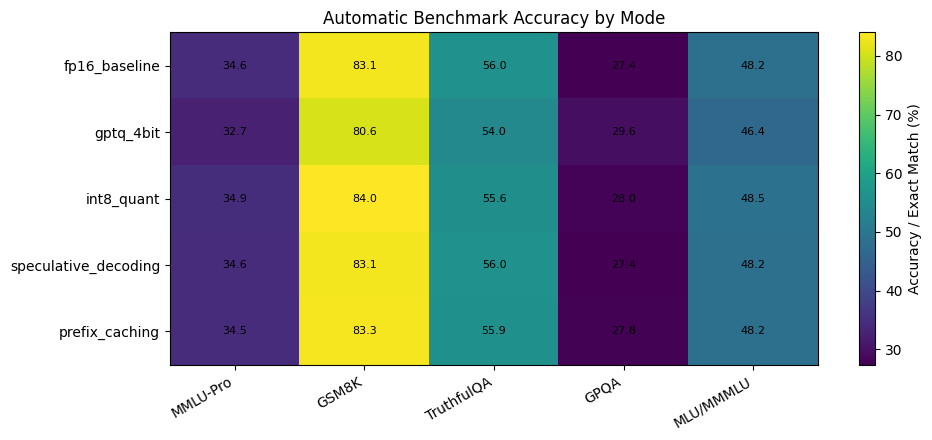

In [16]:
# ============================================================
# Cell 17: Accuracy Plot
# ============================================================

if len(automatic_accuracy_df) > 0:
    automatic_accuracy_matrix = (
        automatic_accuracy_df
        .pivot(index="mode_name", columns="benchmark_label", values="metric_display_value")
        .reindex(
            index=BENCHMARK_MODE_ORDER,
            columns=[
                BENCHMARK_LABELS[w]
                for w in AUTOMATIC_BENCHMARK_DISPLAY_ORDER
                if w in BENCHMARK_LABELS
            ],
        )
    )

    plot_annotated_heatmap(
        automatic_accuracy_matrix,
        title="Automatic Benchmark Accuracy by Mode",
        cbar_label="Accuracy / Exact Match (%)",
        fmt="{:.1f}",
        figsize=(10, 4.5),
        cmap="viridis",
        save_name="automatic_accuracy_heatmap.png",
    )

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/total_latency_heatmap.png


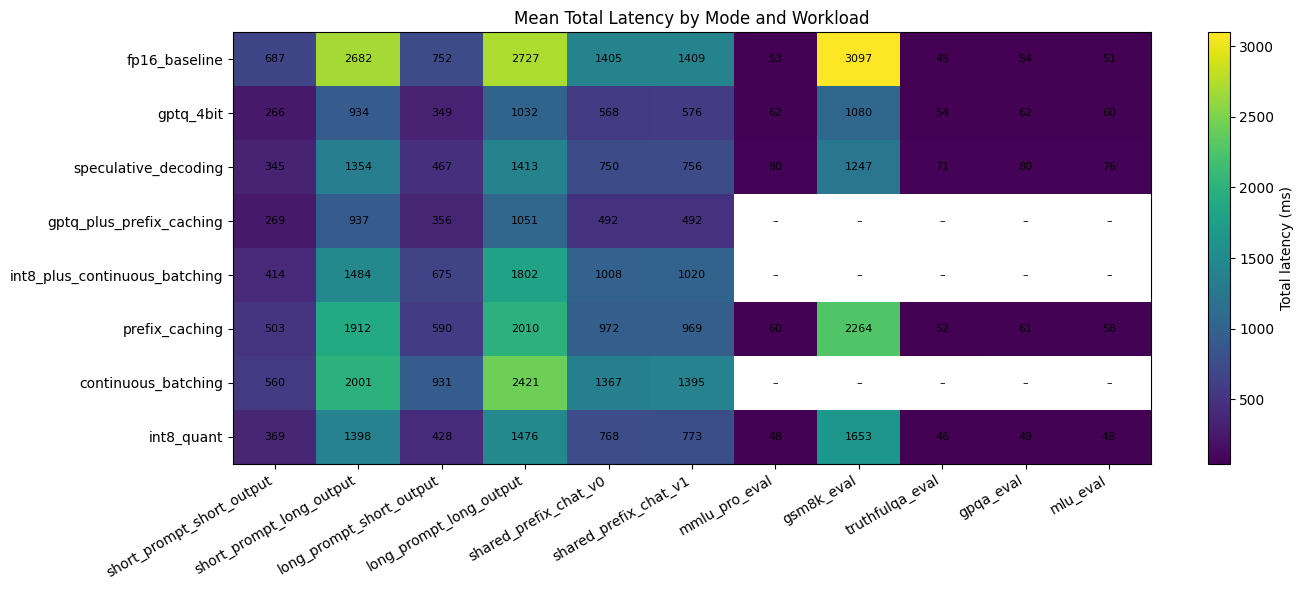

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/throughput_heatmap.png


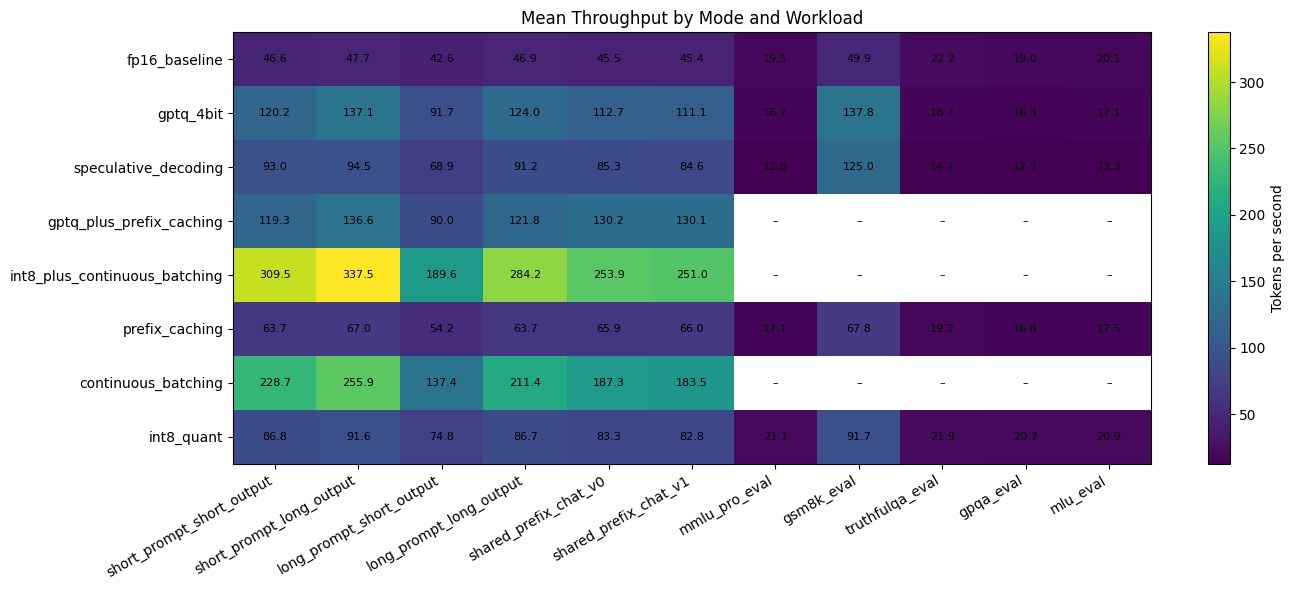

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/energy_per_token_heatmap.png


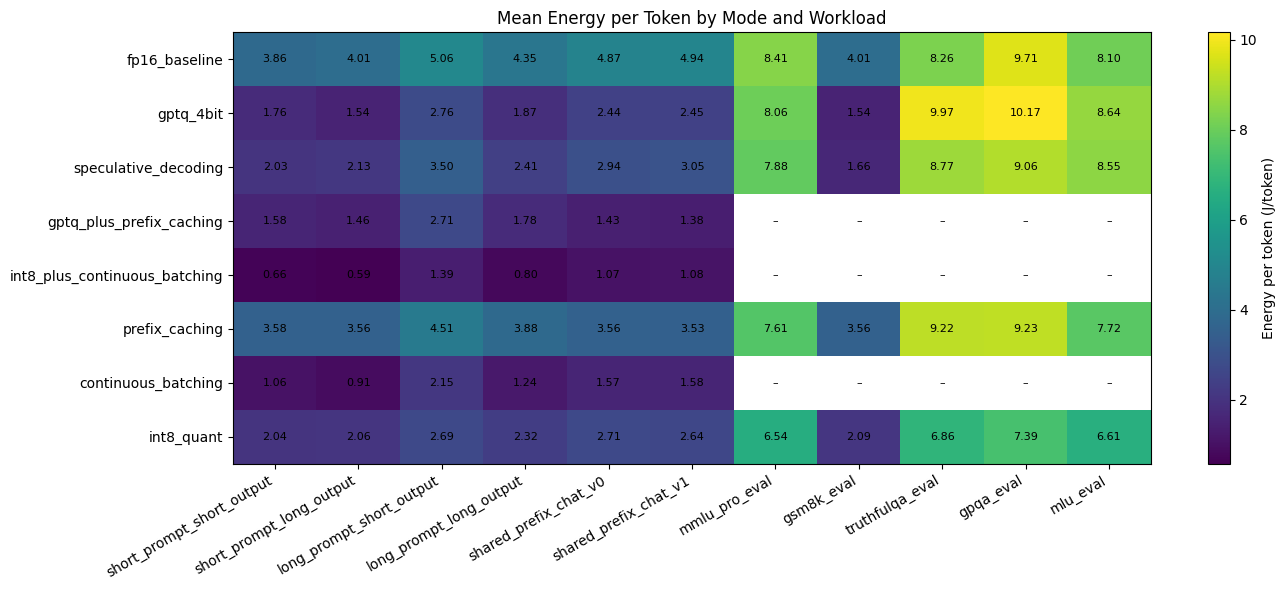

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/peak_gpu_memory_heatmap.png


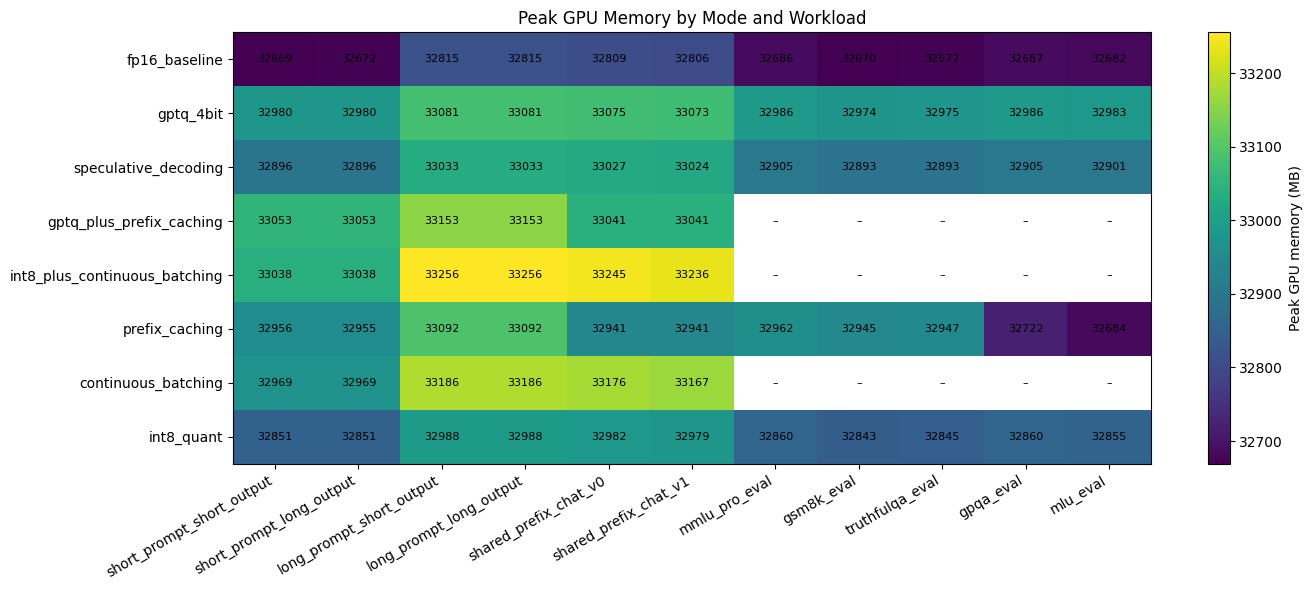

In [17]:
# ============================================================
# Cell 18: Performance heatmaps
# ============================================================

for value_col, title, cbar_label, fmt, save_name in [
    ("total_latency_ms_mean", "Mean Total Latency by Mode and Workload", "Total latency (ms)", "{:.0f}", "total_latency_heatmap.png"),
    ("tokens_per_second_mean", "Mean Throughput by Mode and Workload", "Tokens per second", "{:.1f}", "throughput_heatmap.png"),
    ("energy_per_token_j_mean", "Mean Energy per Token by Mode and Workload", "Energy per token (J/token)", "{:.2f}", "energy_per_token_heatmap.png"),
    ("peak_gpu_memory_mb_mean", "Peak GPU Memory by Mode and Workload", "Peak GPU memory (MB)", "{:.0f}", "peak_gpu_memory_heatmap.png"),
]:
    matrix = (
        dense_agg_df
        .pivot(index="mode_name", columns="workload_name", values=value_col)
        .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
    )

    plot_annotated_heatmap(
        matrix,
        title=title,
        cbar_label=cbar_label,
        fmt=fmt,
        figsize=(14, 6),
        cmap="viridis",
        save_name=save_name,
    )

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/latency_speedup_vs_baseline_heatmap.png


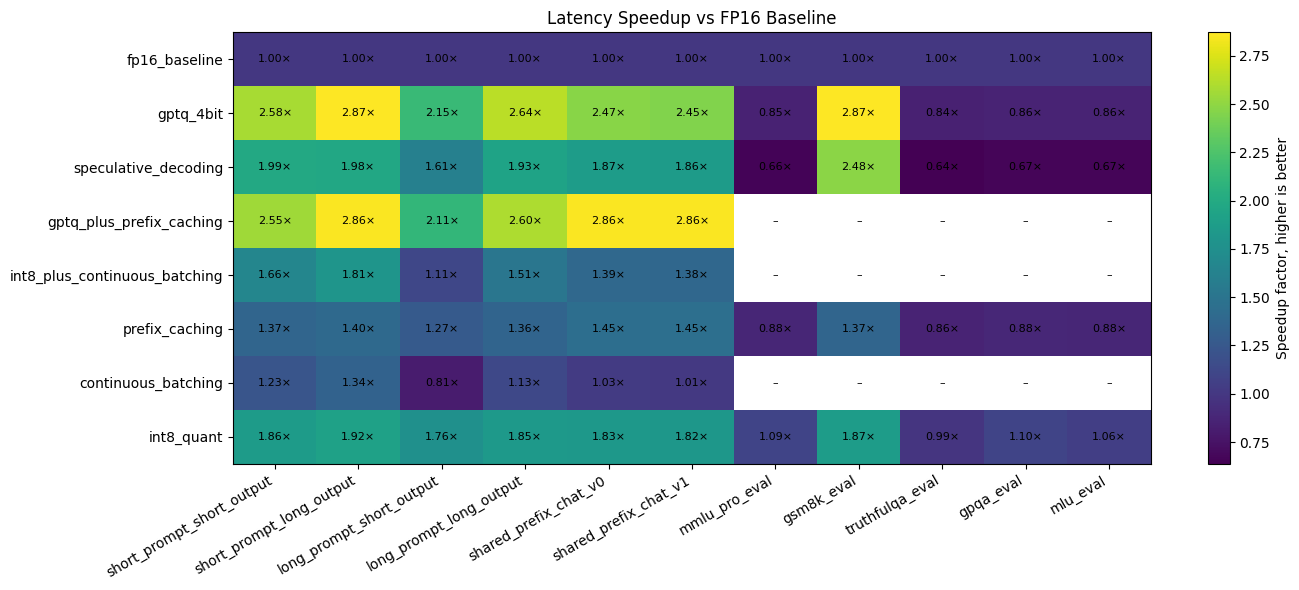

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/energy_ratio_vs_baseline_heatmap.png


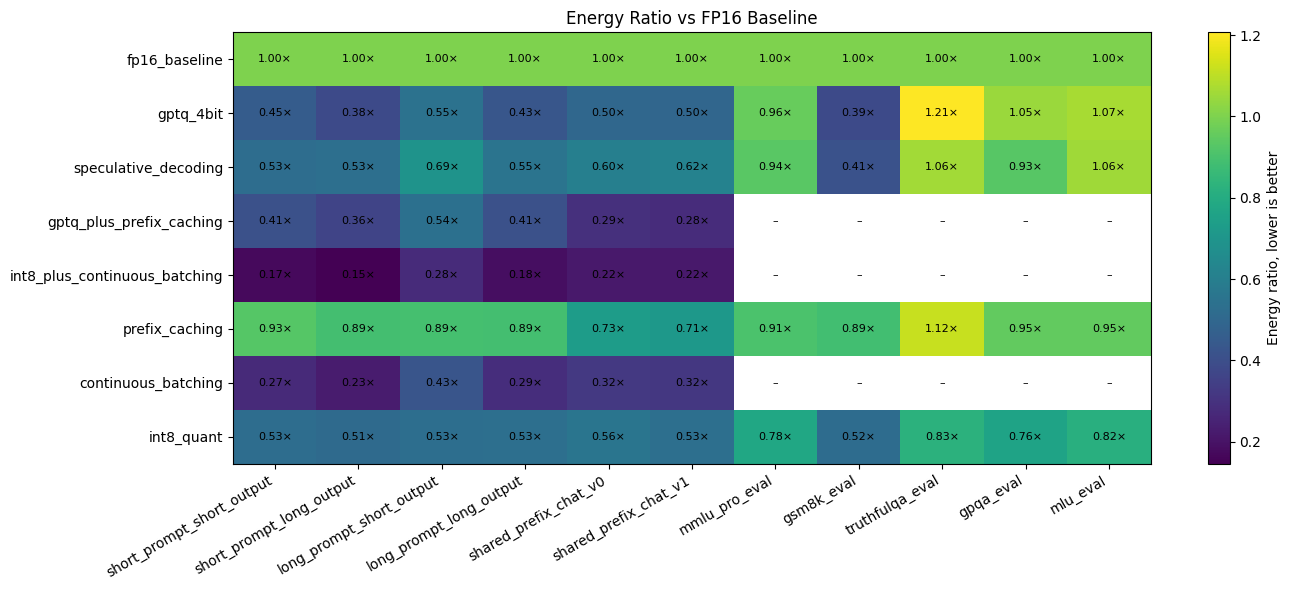

(<Figure size 1400x600 with 2 Axes>,
 <Axes: title={'center': 'Energy Ratio vs FP16 Baseline'}>)

In [18]:
# ============================================================
# Cell 19: Baseline ratio heatmaps
# ============================================================

speedup_matrix = (
    dense_perf_df
    .pivot(index="mode_name", columns="workload_name", values="latency_speedup_vs_baseline")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

plot_annotated_heatmap(
    speedup_matrix,
    title="Latency Speedup vs FP16 Baseline",
    cbar_label="Speedup factor, higher is better",
    fmt="{:.2f}×",
    figsize=(14, 6),
    cmap="viridis",
    save_name="latency_speedup_vs_baseline_heatmap.png",
)

energy_ratio_matrix = (
    dense_perf_df
    .pivot(index="mode_name", columns="workload_name", values="energy_ratio_vs_baseline")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

plot_annotated_heatmap(
    energy_ratio_matrix,
    title="Energy Ratio vs FP16 Baseline",
    cbar_label="Energy ratio, lower is better",
    fmt="{:.2f}×",
    figsize=(14, 6),
    cmap="viridis",
    save_name="energy_ratio_vs_baseline_heatmap.png",
)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/prefill_share_heatmap.png


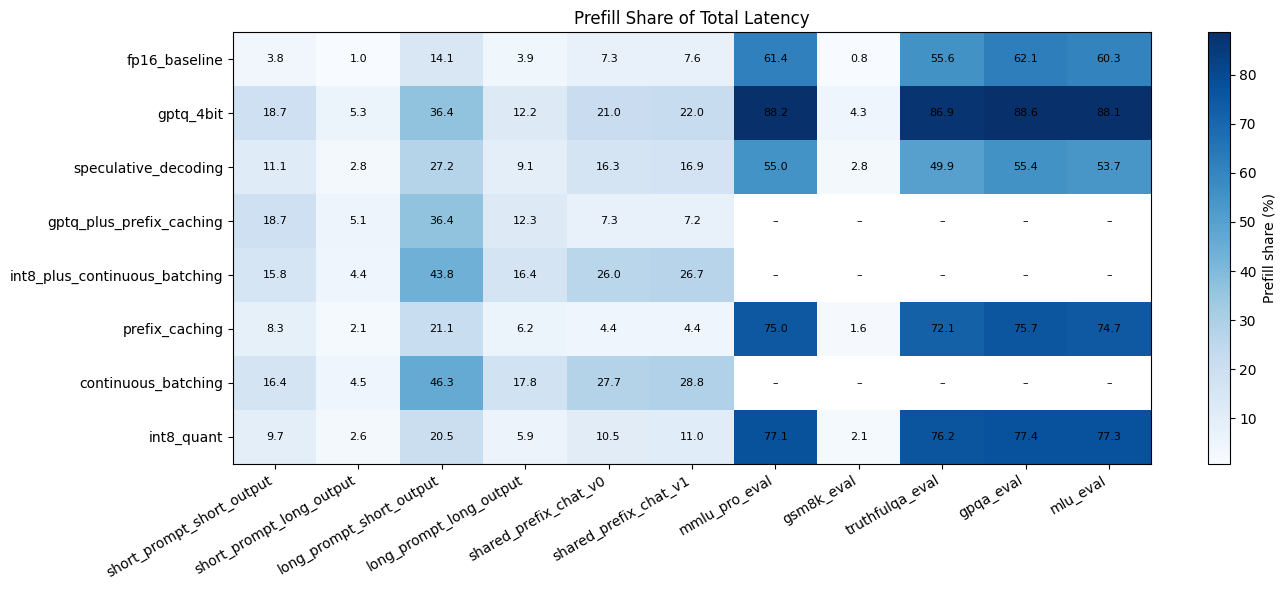

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/decode_share_heatmap.png


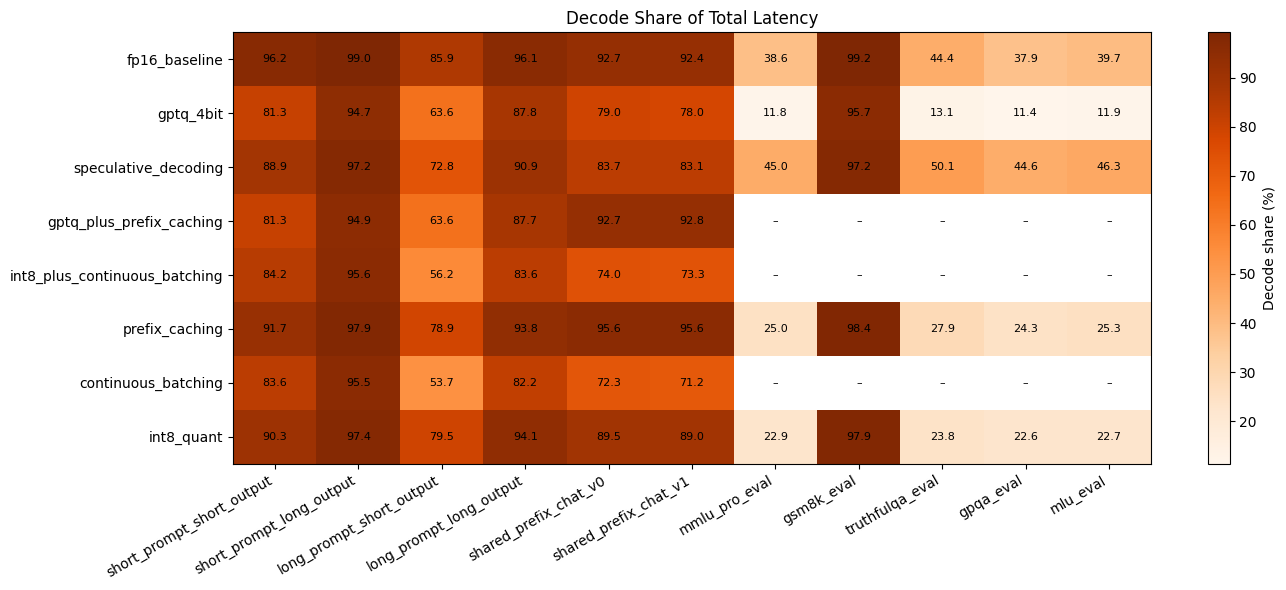

(<Figure size 1400x600 with 2 Axes>,
 <Axes: title={'center': 'Decode Share of Total Latency'}>)

In [19]:
# ============================================================
# Cell 20: Phase dominance heatmaps
# ============================================================

prefill_matrix = (
    dense_phase_df
    .pivot(index="mode_name", columns="workload_name", values="prefill_pct")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

decode_matrix = (
    dense_phase_df
    .pivot(index="mode_name", columns="workload_name", values="decode_pct")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

plot_annotated_heatmap(
    prefill_matrix,
    title="Prefill Share of Total Latency",
    cbar_label="Prefill share (%)",
    fmt="{:.1f}",
    figsize=(14, 6),
    cmap="Blues",
    save_name="prefill_share_heatmap.png",
)

plot_annotated_heatmap(
    decode_matrix,
    title="Decode Share of Total Latency",
    cbar_label="Decode share (%)",
    fmt="{:.1f}",
    figsize=(14, 6),
    cmap="Oranges",
    save_name="decode_share_heatmap.png",
)

In [20]:
# ============================================================
# Cell 21: Best mode tables
# ============================================================

best_latency_df = (
    dense_perf_df
    .sort_values(["workload_name", "total_latency_ms_mean"])
    .groupby("workload_name", as_index=False)
    .first()
)

best_energy_df = (
    dense_perf_df
    .sort_values(["workload_name", "energy_per_token_j_mean"])
    .groupby("workload_name", as_index=False)
    .first()
)

best_throughput_df = (
    dense_perf_df
    .sort_values(["workload_name", "tokens_per_second_mean"], ascending=[True, False])
    .groupby("workload_name", as_index=False)
    .first()
)

best_latency_df = best_latency_df[
    [
        "workload_name",
        "mode_name",
        "total_latency_ms_mean",
        "latency_speedup_vs_baseline",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "energy_ratio_vs_baseline",
        "peak_gpu_memory_mb_mean",
    ]
]

best_energy_df = best_energy_df[
    [
        "workload_name",
        "mode_name",
        "energy_per_token_j_mean",
        "energy_ratio_vs_baseline",
        "total_latency_ms_mean",
        "latency_speedup_vs_baseline",
        "tokens_per_second_mean",
        "peak_gpu_memory_mb_mean",
    ]
]

best_throughput_df = best_throughput_df[
    [
        "workload_name",
        "mode_name",
        "tokens_per_second_mean",
        "throughput_ratio_vs_baseline",
        "total_latency_ms_mean",
        "latency_speedup_vs_baseline",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]
]

save_table(best_latency_df, "best_mode_by_latency.csv")
save_table(best_energy_df, "best_mode_by_energy.csv")
save_table(best_throughput_df, "best_mode_by_throughput.csv")

print("Best by latency:")
display(best_latency_df)

print("Best by energy:")
display(best_energy_df)

print("Best by throughput:")
display(best_throughput_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/best_mode_by_latency.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/best_mode_by_energy.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/best_mode_by_throughput.csv
Best by latency:


,workload_name,mode_name,total_latency_ms_mean,latency_speedup_vs_baseline,tokens_per_second_mean,energy_per_token_j_mean,energy_ratio_vs_baseline,peak_gpu_memory_mb_mean
0,gpqa_eval,int8_quant,48.720628,1.100377,20.697344,7.391704,0.761147,32860.151180
1,gsm8k_eval,gptq_4bit,1079.589608,2.868821,137.820215,1.543560,0.385198,32973.724598
2,long_prompt_long_output,gptq_4bit,1032.489526,2.641278,123.974804,1.868317,0.429922,33080.685059
3,long_prompt_short_output,gptq_4bit,348.882446,2.154126,91.737313,2.760373,0.546067,33080.685059
4,memory_pressure_long_context_v0,gptq_4bit,1139.024584,2.370499,112.381829,2.153066,0.468725,37022.242676
5,memory_pressure_long_context_v1,gptq_4bit,1135.358428,2.392920,112.744386,2.162921,0.475060,37021.617676
6,memory_pressure_long_context_v2,gptq_4bit,1144.883618,2.376142,111.809902,2.141677,0.467168,37025.837891
7,memory_pressure_long_context_v3,gptq_4bit,1135.962190,2.379455,112.682802,2.129039,0.473250,37017.866211
8,memory_pressure_long_context_v4,gptq_4bit,1134.975748,2.387366,112.781998,2.141704,0.474010,37022.008301
9,memory_pressure_long_context_v5,gptq_4bit,1131.649780,2.395181,113.110828,2.155734,0.476645,37014.116211


Best by energy:


,workload_name,mode_name,energy_per_token_j_mean,energy_ratio_vs_baseline,total_latency_ms_mean,latency_speedup_vs_baseline,tokens_per_second_mean,peak_gpu_memory_mb_mean
0,gpqa_eval,int8_quant,7.391704,0.761147,48.720628,1.100377,20.697344,32860.151180
1,gsm8k_eval,gptq_4bit,1.543560,0.385198,1079.589608,2.868821,137.820215,32973.724598
2,long_prompt_long_output,int8_plus_continuous_batching,0.803653,0.184930,1801.890680,1.513461,284.152195,33255.561523
3,long_prompt_short_output,int8_plus_continuous_batching,1.391090,0.275191,675.038462,1.113324,189.630160,33255.561523
4,memory_pressure_long_context_v0,int8_plus_continuous_batching,1.011956,0.220304,2092.280948,1.290485,244.711671,36969.417480
5,memory_pressure_long_context_v1,int8_plus_continuous_batching,1.009824,0.221796,2094.349374,1.297215,244.472201,36968.792480
6,memory_pressure_long_context_v2,int8_plus_continuous_batching,1.036921,0.226186,2109.159114,1.289806,242.757345,36976.278320
7,memory_pressure_long_context_v3,int8_plus_continuous_batching,1.017574,0.226190,2086.539466,1.295432,245.385784,36963.214355
8,memory_pressure_long_context_v4,int8_plus_continuous_batching,1.025638,0.226998,2091.288863,1.295661,244.829097,36969.183105
9,memory_pressure_long_context_v5,int8_plus_continuous_batching,1.017570,0.224991,2083.110846,1.301182,245.790987,36958.689453


Best by throughput:


,workload_name,mode_name,tokens_per_second_mean,throughput_ratio_vs_baseline,total_latency_ms_mean,latency_speedup_vs_baseline,energy_per_token_j_mean,peak_gpu_memory_mb_mean
0,gpqa_eval,int8_quant,20.697344,1.086553,48.720628,1.100377,7.391704,32860.151180
1,gsm8k_eval,gptq_4bit,137.820215,2.762071,1079.589608,2.868821,1.543560,32973.724598
2,long_prompt_long_output,int8_plus_continuous_batching,284.152195,6.053514,1801.890680,1.513461,0.803653,33255.561523
3,long_prompt_short_output,int8_plus_continuous_batching,189.630160,4.453227,675.038462,1.113324,1.391090,33255.561523
4,memory_pressure_long_context_v0,int8_plus_continuous_batching,244.711671,5.161552,2092.280948,1.290485,1.011956,36969.417480
5,memory_pressure_long_context_v1,int8_plus_continuous_batching,244.472201,5.188630,2094.349374,1.297215,1.009824,36968.792480
6,memory_pressure_long_context_v2,int8_plus_continuous_batching,242.757345,5.158953,2109.159114,1.289806,1.036921,36976.278320
7,memory_pressure_long_context_v3,int8_plus_continuous_batching,245.385784,5.181394,2086.539466,1.295432,1.017574,36963.214355
8,memory_pressure_long_context_v4,int8_plus_continuous_batching,244.829097,5.182465,2091.288863,1.295661,1.025638,36969.183105
9,memory_pressure_long_context_v5,int8_plus_continuous_batching,245.790987,5.204479,2083.110846,1.301182,1.017570,36958.689453


In [21]:
# ============================================================
# Cell 22: List saved plots and tables
# ============================================================

print("Saved plots:")
for path in sorted(PLOT_DIR.glob("*")):
    print(" -", path)

print("\nSaved tables:")
for path in sorted(TABLE_DIR.glob("*")):
    print(" -", path)

print("\nFinal dense result files:")
maybe_paths = [
    globals().get("dense_json_path"),
    globals().get("dense_csv_path"),
    globals().get("dense_summary_csv_path"),
    globals().get("dense_aggregate_csv_path"),
    globals().get("dense_comparison_csv_path"),
    globals().get("dense_error_csv_path"),
    globals().get("dense_report_dir"),
    globals().get("judge_sidecar_path"),
]

for path in maybe_paths:
    if path is not None:
        print(" -", path)

Saved plots:
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/automatic_accuracy_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/decode_share_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/energy_per_token_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/energy_ratio_vs_baseline_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/latency_speedup_vs_baseline_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/peak_gpu_memory_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/prefill_share_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_202

In [22]:
# ============================================================
# Cell 23: Offline controller routing from measured real modes
# ============================================================

CONTROLLER_WORKLOAD_FEATURES = {
    "short_prompt_short_output": dict(
        prompt_tokens=128,
        expected_output_tokens=32,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="synthetic_interactive",
    ),
    "short_prompt_long_output": dict(
        prompt_tokens=128,
        expected_output_tokens=128,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="synthetic_generation",
    ),
    "long_prompt_short_output": dict(
        prompt_tokens=1024,
        expected_output_tokens=32,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="synthetic_interactive",
    ),
    "long_prompt_long_output": dict(
        prompt_tokens=1024,
        expected_output_tokens=128,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="synthetic_generation",
    ),
    "shared_prefix_chat_v0": dict(
        prompt_tokens=1024,
        expected_output_tokens=64,
        shared_prefix=True,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="chat_shared_prefix",
    ),
    "shared_prefix_chat_v1": dict(
        prompt_tokens=1024,
        expected_output_tokens=64,
        shared_prefix=True,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="chat_shared_prefix",
    ),
    "memory_pressure_long_context": dict(
        prompt_tokens=2048,
        expected_output_tokens=128,
        shared_prefix=False,
        memory_pressure=True,
        batch_pressure="normal",
        workload_tag="synthetic_long_context",
    ),
    "mmlu_pro_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=8,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="mmlu_pro",
    ),
    "gsm8k_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=384,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="gsm8k",
    ),
    "truthfulqa_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=8,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="truthfulqa",
    ),
    "gpqa_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=8,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="gpqa",
    ),
    "mlu_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=8,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="mlu",
    ),
}

measured_workloads = set(dense_agg_df["workload_name"].dropna())
measured_pairs = set(zip(dense_agg_df["mode_name"], dense_agg_df["workload_name"]))

controller_route_rows = []

for workload_name in WORKLOAD_ORDER_REPORT:
    if workload_name not in measured_workloads:
        continue

    if workload_name not in CONTROLLER_WORKLOAD_FEATURES:
        print("Skipping missing controller features:", workload_name)
        continue

    feature_kwargs = CONTROLLER_WORKLOAD_FEATURES[workload_name]
    features = RequestFeatures(**feature_kwargs)
    classification = classify_request(features)
    decision = route_request(features)

    controller_route_rows.append({
        "workload_name": workload_name,
        "prompt_tokens": features.prompt_tokens,
        "expected_output_tokens": features.expected_output_tokens,
        "shared_prefix": features.shared_prefix,
        "memory_pressure": features.memory_pressure,
        "batch_pressure": features.batch_pressure,
        "workload_tag": features.workload_tag,
        "controller_phase_label": classification.label,
        "controller_estimated_prefill_share_pct": classification.estimated_prefill_share_pct,
        "controller_selected_mode_name": decision.selected_mode_name,
        "controller_route_reason": decision.reason,
        "selected_pair_available": (decision.selected_mode_name, workload_name) in measured_pairs,
    })

controller_routing_df = pd.DataFrame(controller_route_rows)

missing_controller_routes = controller_routing_df[~controller_routing_df["selected_pair_available"]]
if len(missing_controller_routes) > 0:
    display(missing_controller_routes)
    raise ValueError(
        "The controller selected modes that were not measured. "
        "Add those modes to STANDARD_DENSE_MODES or BENCHMARK_DENSE_MODES and rerun."
    )

print("Offline controller routing table:")
display(controller_routing_df)

Offline controller routing table:


,workload_name,prompt_tokens,expected_output_tokens,shared_prefix,memory_pressure,batch_pressure,workload_tag,controller_phase_label,controller_estimated_prefill_share_pct,controller_selected_mode_name,controller_route_reason,selected_pair_available
0,short_prompt_short_output,128,32,False,False,normal,synthetic_interactive,decode_heavy,0.0,speculative_decoding,Short interactive request: route to speculativ...,True
1,short_prompt_long_output,128,128,False,False,normal,synthetic_generation,decode_heavy,0.0,speculative_decoding,Decode-heavy long-generation workload: route t...,True
2,long_prompt_short_output,1024,32,False,False,normal,synthetic_interactive,decode_heavy,35.0,int8_quant,Long or prefill-heavy request without a reusab...,True
3,long_prompt_long_output,1024,128,False,False,normal,synthetic_generation,decode_heavy,0.0,speculative_decoding,Decode-heavy long-generation workload: route t...,True
4,shared_prefix_chat_v0,1024,64,True,False,normal,chat_shared_prefix,chat_shared_prefix,0.0,gptq_plus_prefix_caching,Shared-prefix chat request: route to GPTQ + pr...,True
5,shared_prefix_chat_v1,1024,64,True,False,normal,chat_shared_prefix,chat_shared_prefix,0.0,gptq_plus_prefix_caching,Shared-prefix chat request: route to GPTQ + pr...,True
6,mmlu_pro_eval,512,8,False,False,normal,mmlu_pro,prefill_heavy,65.0,int8_quant,Automatically scored multiple-choice benchmark...,True
7,gsm8k_eval,512,384,False,False,normal,gsm8k,decode_heavy,0.0,speculative_decoding,GSM8K uses longer generated reasoning answers....,True
8,truthfulqa_eval,512,8,False,False,normal,truthfulqa,prefill_heavy,65.0,int8_quant,Automatically scored multiple-choice benchmark...,True
9,gpqa_eval,512,8,False,False,normal,gpqa,prefill_heavy,65.0,int8_quant,Automatically scored multiple-choice benchmark...,True


In [23]:
# ============================================================
# Cell 24: Offline controller vs FP16 performance
# ============================================================

controller_perf_df = controller_routing_df.merge(
    dense_agg_df,
    left_on=["controller_selected_mode_name", "workload_name"],
    right_on=["mode_name", "workload_name"],
    how="left",
)

fp16_perf_df = (
    dense_agg_df[dense_agg_df["mode_name"] == "fp16_baseline"]
    [[
        "workload_name",
        "total_latency_ms_mean",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]]
    .rename(columns={
        "total_latency_ms_mean": "fp16_total_latency_ms_mean",
        "tokens_per_second_mean": "fp16_tokens_per_second_mean",
        "energy_per_token_j_mean": "fp16_energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean": "fp16_peak_gpu_memory_mb_mean",
    })
)

controller_perf_df = controller_perf_df.merge(fp16_perf_df, on="workload_name", how="left")

controller_perf_df["latency_speedup"] = (
    controller_perf_df["fp16_total_latency_ms_mean"] / controller_perf_df["total_latency_ms_mean"]
)
controller_perf_df["throughput_ratio"] = (
    controller_perf_df["tokens_per_second_mean"] / controller_perf_df["fp16_tokens_per_second_mean"]
)
controller_perf_df["energy_ratio"] = (
    controller_perf_df["energy_per_token_j_mean"] / controller_perf_df["fp16_energy_per_token_j_mean"]
)
controller_perf_df["memory_ratio"] = (
    controller_perf_df["peak_gpu_memory_mb_mean"] / controller_perf_df["fp16_peak_gpu_memory_mb_mean"]
)

controller_fp16_compare_df = controller_perf_df[[
    "workload_name",
    "controller_selected_mode_name",
    "controller_phase_label",
    "controller_estimated_prefill_share_pct",
    "total_latency_ms_mean",
    "fp16_total_latency_ms_mean",
    "latency_speedup",
    "tokens_per_second_mean",
    "fp16_tokens_per_second_mean",
    "throughput_ratio",
    "energy_per_token_j_mean",
    "fp16_energy_per_token_j_mean",
    "energy_ratio",
    "peak_gpu_memory_mb_mean",
    "fp16_peak_gpu_memory_mb_mean",
    "memory_ratio",
    "controller_route_reason",
]].sort_values("latency_speedup", ascending=False).reset_index(drop=True)

save_table(controller_fp16_compare_df, "offline_controller_vs_fp16_performance.csv")
display(controller_fp16_compare_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/offline_controller_vs_fp16_performance.csv


,workload_name,controller_selected_mode_name,controller_phase_label,controller_estimated_prefill_share_pct,total_latency_ms_mean,fp16_total_latency_ms_mean,latency_speedup,tokens_per_second_mean,fp16_tokens_per_second_mean,throughput_ratio,energy_per_token_j_mean,fp16_energy_per_token_j_mean,energy_ratio,peak_gpu_memory_mb_mean,fp16_peak_gpu_memory_mb_mean,memory_ratio,controller_route_reason
0,shared_prefix_chat_v1,gptq_plus_prefix_caching,chat_shared_prefix,0.0,492.350561,1409.486694,2.862771,130.105342,45.411798,2.865012,1.384882,4.942872,0.280178,33040.586735,32806.063477,1.007149,Shared-prefix chat request: route to GPTQ + pr...
1,shared_prefix_chat_v0,gptq_plus_prefix_caching,chat_shared_prefix,0.0,491.950552,1405.438577,2.856870,130.216673,45.542951,2.859206,1.427403,4.871498,0.293011,33040.923763,32808.922852,1.007071,Shared-prefix chat request: route to GPTQ + pr...
2,gsm8k_eval,speculative_decoding,decode_heavy,0.0,1246.715328,3097.149247,2.484247,125.013905,49.897420,2.505418,1.657127,4.007192,0.413538,32892.871893,32669.518399,1.006837,GSM8K uses longer generated reasoning answers....
3,short_prompt_short_output,speculative_decoding,decode_heavy,0.0,345.178729,686.973315,1.990196,92.950681,46.592083,1.994989,2.030322,3.862559,0.525642,32895.517578,32669.332520,1.006923,Short interactive request: route to speculativ...
4,short_prompt_long_output,speculative_decoding,decode_heavy,0.0,1354.365249,2682.208007,1.980417,94.513437,47.726585,1.980310,2.134179,4.009347,0.532301,32895.517578,32672.323145,1.006831,Decode-heavy long-generation workload: route t...
5,long_prompt_long_output,speculative_decoding,decode_heavy,0.0,1412.571250,2727.091607,1.930587,91.169063,46.940042,1.942245,2.407226,4.345715,0.553931,33032.953125,32814.924316,1.006644,Decode-heavy long-generation workload: route t...
6,long_prompt_short_output,int8_quant,decode_heavy,35.0,427.835178,751.536719,1.756603,74.810960,42.582641,1.756842,2.686280,5.055007,0.531410,32988.310059,32814.924316,1.005284,Long or prefill-heavy request without a reusab...
7,gpqa_eval,int8_quant,prefill_heavy,65.0,48.720628,53.611072,1.100377,20.697344,19.048634,1.086553,7.391704,9.711266,0.761147,32860.151180,32686.642629,1.005308,Automatically scored multiple-choice benchmark...
8,mmlu_pro_eval,int8_quant,prefill_heavy,65.0,48.404575,52.887388,1.092611,21.107397,19.530367,1.080748,6.538395,8.410643,0.777395,32859.668904,32686.119033,1.005310,Automatically scored multiple-choice benchmark...
9,mlu_eval,int8_quant,prefill_heavy,65.0,48.356227,51.108888,1.056925,20.907965,20.099523,1.040222,6.612832,8.099489,0.816451,32855.496946,32682.020282,1.005308,Automatically scored multiple-choice benchmark...


In [24]:
# ============================================================
# Cell 25: Offline controller accuracy gate
# ============================================================

controller_accuracy_metric_map = {
    "mmlu_pro_eval": "mmlu_pro_accuracy_mean",
    "gsm8k_eval": "gsm8k_exact_match_accuracy_mean",
    "truthfulqa_eval": "truthfulqa_accuracy_mean",
    "gpqa_eval": "gpqa_accuracy_mean",
    "mlu_eval": "mlu_accuracy_mean",
}

controller_auto_accuracy_rows = []

for workload_name, metric_col in controller_accuracy_metric_map.items():
    if workload_name not in set(dense_agg_df["workload_name"]):
        continue

    if metric_col not in dense_agg_df.columns:
        print("Missing metric column:", metric_col)
        continue

    selected_mode = controller_routing_df.loc[
        controller_routing_df["workload_name"] == workload_name,
        "controller_selected_mode_name",
    ].iloc[0]

    selected_row = dense_agg_df[
        (dense_agg_df["workload_name"] == workload_name)
        & (dense_agg_df["mode_name"] == selected_mode)
    ]
    fp16_row = dense_agg_df[
        (dense_agg_df["workload_name"] == workload_name)
        & (dense_agg_df["mode_name"] == "fp16_baseline")
    ]

    if len(selected_row) == 0 or len(fp16_row) == 0:
        continue

    controller_accuracy_pct = 100.0 * float(selected_row.iloc[0][metric_col])
    fp16_accuracy_pct = 100.0 * float(fp16_row.iloc[0][metric_col])

    controller_auto_accuracy_rows.append({
        "workload_name": workload_name,
        "metric_column": metric_col,
        "controller_selected_mode_name": selected_mode,
        "controller_accuracy_pct": controller_accuracy_pct,
        "fp16_accuracy_pct": fp16_accuracy_pct,
        "delta_pts": controller_accuracy_pct - fp16_accuracy_pct,
    })

controller_auto_accuracy_df = pd.DataFrame(controller_auto_accuracy_rows).sort_values("workload_name").reset_index(drop=True)

if len(controller_auto_accuracy_df) == 0:
    mean_controller_auto_accuracy_pct = np.nan
    mean_fp16_auto_accuracy_pct = np.nan
    mean_accuracy_delta_pts = np.nan
    controller_quality_pass = False
    print("No auto-graded controller accuracy rows were available.")
else:
    mean_controller_auto_accuracy_pct = controller_auto_accuracy_df["controller_accuracy_pct"].mean()
    mean_fp16_auto_accuracy_pct = controller_auto_accuracy_df["fp16_accuracy_pct"].mean()
    mean_accuracy_delta_pts = mean_controller_auto_accuracy_pct - mean_fp16_auto_accuracy_pct
    controller_quality_pass = abs(mean_accuracy_delta_pts) <= 1.5

    print("Mean controller auto-graded accuracy:", round(mean_controller_auto_accuracy_pct, 3))
    print("Mean FP16 auto-graded accuracy:", round(mean_fp16_auto_accuracy_pct, 3))
    print("Mean accuracy delta:", round(mean_accuracy_delta_pts, 3))
    print("Quality threshold result:", "PASS" if controller_quality_pass else "FAIL")

save_table(controller_auto_accuracy_df, "offline_controller_accuracy_gate.csv")
display(controller_auto_accuracy_df)

Mean controller auto-graded accuracy: 50.025
Mean FP16 auto-graded accuracy: 49.86
Mean accuracy delta: 0.165
Quality threshold result: PASS
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/offline_controller_accuracy_gate.csv


,workload_name,metric_column,controller_selected_mode_name,controller_accuracy_pct,fp16_accuracy_pct,delta_pts
0,gpqa_eval,gpqa_accuracy_mean,int8_quant,28.000,27.4,0.600
1,gsm8k_eval,gsm8k_exact_match_accuracy_mean,speculative_decoding,83.100,83.1,0.000
2,mlu_eval,mlu_accuracy_mean,int8_quant,48.500,48.2,0.300
3,mmlu_pro_eval,mmlu_pro_accuracy_mean,int8_quant,34.900,34.6,0.300
4,truthfulqa_eval,truthfulqa_accuracy_mean,int8_quant,55.625,56.0,-0.375


In [25]:
# ============================================================
# Cell 26: Offline controller oracle comparison
# ============================================================

latency_oracle_df = (
    dense_agg_df.dropna(subset=["total_latency_ms_mean"])
    .sort_values(["workload_name", "total_latency_ms_mean"])
    .groupby("workload_name", as_index=False)
    .first()
    [["workload_name", "mode_name", "total_latency_ms_mean"]]
    .rename(columns={
        "mode_name": "latency_oracle_mode_name",
        "total_latency_ms_mean": "latency_oracle_total_latency_ms_mean",
    })
)

energy_oracle_df = (
    dense_agg_df.dropna(subset=["energy_per_token_j_mean"])
    .sort_values(["workload_name", "energy_per_token_j_mean"])
    .groupby("workload_name", as_index=False)
    .first()
    [["workload_name", "mode_name", "energy_per_token_j_mean"]]
    .rename(columns={
        "mode_name": "energy_oracle_mode_name",
        "energy_per_token_j_mean": "energy_oracle_energy_per_token_j_mean",
    })
)

controller_oracle_compare_df = (
    controller_fp16_compare_df
    [[
        "workload_name",
        "controller_selected_mode_name",
        "total_latency_ms_mean",
        "energy_per_token_j_mean",
    ]]
    .rename(columns={
        "total_latency_ms_mean": "controller_total_latency_ms_mean",
        "energy_per_token_j_mean": "controller_energy_per_token_j_mean",
    })
    .merge(latency_oracle_df, on="workload_name", how="left")
    .merge(energy_oracle_df, on="workload_name", how="left")
)

controller_oracle_compare_df["latency_oracle_over_controller"] = (
    controller_oracle_compare_df["latency_oracle_total_latency_ms_mean"]
    / controller_oracle_compare_df["controller_total_latency_ms_mean"]
)
controller_oracle_compare_df["energy_oracle_over_controller"] = (
    controller_oracle_compare_df["energy_oracle_energy_per_token_j_mean"]
    / controller_oracle_compare_df["controller_energy_per_token_j_mean"]
)
controller_oracle_compare_df["matches_latency_oracle_mode"] = (
    controller_oracle_compare_df["controller_selected_mode_name"]
    == controller_oracle_compare_df["latency_oracle_mode_name"]
)
controller_oracle_compare_df["matches_energy_oracle_mode"] = (
    controller_oracle_compare_df["controller_selected_mode_name"]
    == controller_oracle_compare_df["energy_oracle_mode_name"]
)

controller_oracle_compare_df = controller_oracle_compare_df.sort_values("workload_name").reset_index(drop=True)

save_table(controller_oracle_compare_df, "offline_controller_oracle_comparison.csv")
display(controller_oracle_compare_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/offline_controller_oracle_comparison.csv


,workload_name,controller_selected_mode_name,controller_total_latency_ms_mean,controller_energy_per_token_j_mean,latency_oracle_mode_name,latency_oracle_total_latency_ms_mean,energy_oracle_mode_name,energy_oracle_energy_per_token_j_mean,latency_oracle_over_controller,energy_oracle_over_controller,matches_latency_oracle_mode,matches_energy_oracle_mode
0,gpqa_eval,int8_quant,48.720628,7.391704,int8_quant,48.720628,int8_quant,7.391704,1.000000,1.000000,True,True
1,gsm8k_eval,speculative_decoding,1246.715328,1.657127,gptq_4bit,1079.589608,gptq_4bit,1.543560,0.865947,0.931468,False,False
2,long_prompt_long_output,speculative_decoding,1412.571250,2.407226,gptq_4bit,1032.489526,int8_plus_continuous_batching,0.803653,0.730929,0.333850,False,False
3,long_prompt_short_output,int8_quant,427.835178,2.686280,gptq_4bit,348.882446,int8_plus_continuous_batching,1.391090,0.815460,0.517850,False,False
4,mlu_eval,int8_quant,48.356227,6.612832,int8_quant,48.356227,int8_quant,6.612832,1.000000,1.000000,True,True
5,mmlu_pro_eval,int8_quant,48.404575,6.538395,int8_quant,48.404575,int8_quant,6.538395,1.000000,1.000000,True,True
6,shared_prefix_chat_v0,gptq_plus_prefix_caching,491.950552,1.427403,gptq_plus_prefix_caching,491.950552,int8_plus_continuous_batching,1.070245,1.000000,0.749785,True,False
7,shared_prefix_chat_v1,gptq_plus_prefix_caching,492.350561,1.384882,gptq_plus_prefix_caching,492.350561,int8_plus_continuous_batching,1.078247,1.000000,0.778584,True,False
8,short_prompt_long_output,speculative_decoding,1354.365249,2.134179,gptq_4bit,933.879186,int8_plus_continuous_batching,0.586604,0.689533,0.274861,False,False
9,short_prompt_short_output,speculative_decoding,345.178729,2.030322,gptq_4bit,266.297764,int8_plus_continuous_batching,0.661711,0.771478,0.325914,False,False


In [ ]:
# ============================================================
# Cell 27: Final summary tables
# ============================================================

FINAL_TABLE_DIR = TABLE_DIR / "final_paper_tables"
FINAL_TABLE_DIR.mkdir(parents=True, exist_ok=True)

headline_summary_df = pd.DataFrame([{
    "controller_evaluation_type": "offline_request_boundary_routing_from_measured_fixed_modes",
    "mean_latency_speedup": controller_fp16_compare_df["latency_speedup"].mean(),
    "mean_throughput_ratio": controller_fp16_compare_df["throughput_ratio"].mean(),
    "mean_energy_ratio": controller_fp16_compare_df["energy_ratio"].mean(),
    "mean_energy_reduction_pct": 100.0 * (1.0 - controller_fp16_compare_df["energy_ratio"].mean()),
    "mean_memory_ratio": controller_fp16_compare_df["memory_ratio"].mean(),
    "mean_accuracy_delta_pts": mean_accuracy_delta_pts,
    "quality_threshold_pass": "PASS" if controller_quality_pass else "FAIL",
    "quality_scope": "5 auto-graded benchmarks only",
    "external_judge_quality_included": RUN_EXTERNAL_JUDGE_WORKLOADS,
    "memory_claim": "No meaningful GPU memory reduction claimed",
    "oracle_claim": "Controller is compared against oracle but is not oracle-optimal",
    "cache_caveat": (
        "Synthetic repeated trials may favor prefix-caching modes unless unique "
        "trial headers are enabled for future reruns."
    ),
}])

paper_summary_display = pd.DataFrame([
    {
        "Metric": "Controller evaluation type",
        "Value": "Offline routing over measured fixed-mode results",
    },
    {
        "Metric": "Mean latency speedup vs FP16",
        "Value": f"{headline_summary_df.iloc[0]['mean_latency_speedup']:.2f}×",
    },
    {
        "Metric": "Mean throughput ratio vs FP16",
        "Value": f"{headline_summary_df.iloc[0]['mean_throughput_ratio']:.2f}×",
    },
    {
        "Metric": "Mean energy ratio vs FP16",
        "Value": (
            f"{headline_summary_df.iloc[0]['mean_energy_ratio']:.2f}× "
            f"({headline_summary_df.iloc[0]['mean_energy_reduction_pct']:.1f}% lower)"
        ),
    },
    {
        "Metric": "Mean GPU memory ratio vs FP16",
        "Value": f"{headline_summary_df.iloc[0]['mean_memory_ratio']:.3f}× (unchanged)",
    },
    {
        "Metric": "Mean accuracy delta",
        "Value": f"{headline_summary_df.iloc[0]['mean_accuracy_delta_pts']:.2f} points",
    },
    {
        "Metric": "Quality threshold",
        "Value": headline_summary_df.iloc[0]["quality_threshold_pass"],
    },
    {
        "Metric": "Quality scope",
        "Value": "5 auto-graded benchmarks only; external judge workloads excluded",
    },
    {
        "Metric": "Oracle status",
        "Value": "Not oracle-optimal; oracle gap reported separately",
    },
])

headline_summary_df.to_csv(FINAL_TABLE_DIR / "headline_summary.csv", index=False)
paper_summary_display.to_csv(FINAL_TABLE_DIR / "paper_headline_table.csv", index=False)
paper_summary_display.to_latex(FINAL_TABLE_DIR / "paper_headline_table.tex", index=False, escape=False)
controller_routing_df.to_csv(FINAL_TABLE_DIR / "controller_routing_table.csv", index=False)
controller_fp16_compare_df.to_csv(FINAL_TABLE_DIR / "controller_vs_fp16_performance.csv", index=False)
controller_auto_accuracy_df.to_csv(FINAL_TABLE_DIR / "controller_accuracy_gate.csv", index=False)
controller_oracle_compare_df.to_csv(FINAL_TABLE_DIR / "controller_oracle_comparison.csv", index=False)

print("Final paper summary:")
display(paper_summary_display)

print("Saved final paper tables to:", FINAL_TABLE_DIR)
for path in sorted(FINAL_TABLE_DIR.glob("*")):
    print(" -", path)

Final paper summary:


,Metric,Value
0,Controller evaluation type,Offline routing over measured fixed-mode results
1,Mean latency speedup vs FP16,1.83×
2,Mean throughput ratio vs FP16,1.83×
3,Mean energy ratio vs FP16,0.57× (42.6% lower)
4,Mean GPU memory ratio vs FP16,1.006× (unchanged)
5,Mean accuracy delta,0.16 points
6,Quality threshold,PASS
7,Quality scope,5 auto-graded benchmarks only; external judge ...
8,Oracle status,Not oracle-optimal; oracle gap reported separa...


Saved final paper tables to: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables/controller_accuracy_gate.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables/controller_oracle_comparison.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables/controller_routing_table.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables/controller_vs_fp16_performance.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables/headline_summary.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506

In [27]:
# ============================================================
# Cell 28: Online request-boundary controller execution
# ============================================================

from collections import defaultdict
from metrics import now_s
from controller import route_runtime_workload
from model_loader import load_model_for_mode, unload_model

ONLINE_CONTROLLER_MODE_NAME = "online_request_boundary_controller"

# Full online controller run is much cheaper than the full fixed-mode sweep:
# it runs only the controller-selected mode for each workload, not every mode.
ONLINE_CONTROLLER_WORKLOADS = FINAL_DENSE_WORKLOADS

online_controller_results = []
online_controller_error_rows = []

online_run_stamp = time.strftime("%Y%m%d_%H%M%S")
online_json_path = RAW_RESULTS_DIR / f"online_controller_results_{online_run_stamp}.json"
online_csv_path = RAW_RESULTS_DIR / f"online_controller_results_{online_run_stamp}.csv"

RESUME_ONLINE_CONTROLLER = True
ONLINE_RESUME_JSON_PATH = None

online_existing_raw_rows = []
online_completed_keys = set()

if RESUME_ONLINE_CONTROLLER:
    if ONLINE_RESUME_JSON_PATH is None:
        ONLINE_RESUME_JSON_PATH = find_latest_json_checkpoint(
            RAW_RESULTS_DIR,
            patterns=[
                "online_controller_results_*.json",
            ],
        )

    if ONLINE_RESUME_JSON_PATH is not None:
        online_existing_raw_rows = load_json_rows(ONLINE_RESUME_JSON_PATH)
        online_completed_keys = {
            key
            for key in (run_key_from_row(row) for row in online_existing_raw_rows)
            if key is not None
        }

        print("Resuming online controller from:", ONLINE_RESUME_JSON_PATH)
        print("Previously completed online runs:", len(online_completed_keys))
    else:
        print("No online controller checkpoint found. Starting from scratch.")
    
# First pass: route each workload before execution, then group by selected mode
# so each selected model is loaded once.
online_plan_rows = []

for workload_name in ONLINE_CONTROLLER_WORKLOADS:
    runtime_workload = resolve_runtime_workload(workload_name)
    decision = route_runtime_workload(runtime_workload)

    online_plan_rows.append({
        "workload_name": workload_name,
        "workload_group": canonical_workload_group_name(workload_name),
        "selected_mode_name": decision.selected_mode_name,
        "classification_label": decision.classification_label,
        "estimated_prefill_share_pct": decision.estimated_prefill_share_pct,
        "route_reason": decision.reason,
        "trials": trials_for_workload(workload_name),
    })

online_plan_df = pd.DataFrame(online_plan_rows)
display(
    online_plan_df
    .groupby(["workload_group", "selected_mode_name"], as_index=False)
    .agg(
        num_expanded_workloads=("workload_name", "nunique"),
        trials=("trials", "sum"),
    )
)

mode_to_online_workloads = defaultdict(list)
for row in online_plan_rows:
    mode_to_online_workloads[row["selected_mode_name"]].append(row)

online_total_runs = sum(row["trials"] for row in online_plan_rows)
online_run_counter = len(online_completed_keys)

try:
    for selected_mode_name, rows in mode_to_online_workloads.items():
        runtime_mode = resolve_runtime_mode(selected_mode_name)

        print("\n" + "#" * 120)
        print(f"ONLINE CONTROLLER SELECTED MODE: {selected_mode_name}")
        print(f"Workloads routed here: {len(rows)}")
        print("#" * 120)

        bundle = None

        try:
            bundle = load_model_for_mode(runtime_mode)

            for plan_row in rows:
                workload_name = plan_row["workload_name"]
                n_trials = int(plan_row["trials"])

                for trial_index in range(n_trials):
                    run_key = (ONLINE_CONTROLLER_MODE_NAME, workload_name, trial_index)

                    if run_key in online_completed_keys:
                        continue
                    online_run_counter += 1

                    try:
                        runtime_workload = resolve_runtime_workload(workload_name)

                        # Route immediately before execution.
                        # This is the online decision point.
                        route_start_s = now_s(sync_cuda=False)
                        decision = route_runtime_workload(runtime_workload)
                        route_end_s = now_s(sync_cuda=False)
                        route_overhead_ms = (route_end_s - route_start_s) * 1000.0

                        if decision.selected_mode_name != selected_mode_name:
                            raise RuntimeError(
                                f"Route changed unexpectedly for {workload_name}: "
                                f"{selected_mode_name} -> {decision.selected_mode_name}"
                            )

                        result = run_single_benchmark(
                            runtime_mode=runtime_mode,
                            workload=runtime_workload,
                            trial_index=trial_index,
                            preloaded_bundle=bundle,
                        )

                        # Rewrite the visible mode name to represent the online controller,
                        # while preserving the real delegated mode in controller metadata.
                        result.mode_name = ONLINE_CONTROLLER_MODE_NAME
                        result.controller_selected_mode_name = decision.selected_mode_name
                        result.controller_phase_label = decision.classification_label
                        result.controller_estimated_prefill_share_pct = decision.estimated_prefill_share_pct
                        result.controller_route_reason = decision.reason
                        result.controller_routing_overhead_ms = route_overhead_ms
                        result.controller_decision_source = "online_before_execution"
                        result.evaluation_scope = "online_request_boundary_controller"

                        result.notes = (
                            f"Online request-boundary controller routed this request to "
                            f"{decision.selected_mode_name}. Routing overhead was "
                            f"{route_overhead_ms:.4f} ms. "
                            + (result.notes or "")
                        )

                        online_controller_results.append(result)
                        online_completed_keys.add(run_key)

                        print(
                            f"[{online_run_counter}/{online_total_runs}] "
                            f"{ONLINE_CONTROLLER_MODE_NAME:36s} -> {selected_mode_name:28s} | "
                            f"{workload_name:48s} | trial={trial_index:02d} | "
                            f"success={result.success} | "
                            f"route_ms={route_overhead_ms:.4f} | "
                            f"lat={fmt_num(result.total_latency_ms)} ms | "
                            f"tps={fmt_num(result.tokens_per_second)} | "
                            f"J/tok={fmt_num(result.energy_per_token_j, 3)}"
                        )

                    except Exception as exc:
                        online_controller_error_rows.append({
                            "selected_mode_name": selected_mode_name,
                            "workload_name": workload_name,
                            "trial_index": trial_index,
                            "error": str(exc),
                        })

                        print(
                            f"[{online_run_counter}/{online_total_runs}] "
                            f"{ONLINE_CONTROLLER_MODE_NAME} | {workload_name} | "
                            f"trial={trial_index:02d} | ERROR={exc}"
                        )

                    if online_run_counter % 25 == 0 and (online_existing_raw_rows or online_controller_results):
                        save_resume_checkpoint(
                            online_existing_raw_rows,
                            online_controller_results,
                            online_json_path,
                            online_csv_path,
                        )
                        print("Online checkpoint saved:", online_json_path)

                    if online_run_counter % 10 == 0:
                        gc.collect()
                        if torch is not None and torch.cuda.is_available():
                            torch.cuda.empty_cache()

        finally:
            if bundle is not None:
                unload_model(bundle)
                gc.collect()
                if torch is not None and torch.cuda.is_available():
                    torch.cuda.empty_cache()

finally:
    print(f"\nCollected {len(online_controller_results)} new online controller result objects this session.")
    print(f"Previously loaded online controller rows: {len(online_existing_raw_rows)}")
    print(f"Logged {len(online_controller_error_rows)} online controller hard errors.")

if online_existing_raw_rows or online_controller_results:
    combined_online_rows = save_resume_checkpoint(
        online_existing_raw_rows,
        online_controller_results,
        online_json_path,
        online_csv_path,
    )
    print("Saved online controller JSON:", online_json_path)
    print("Saved online controller CSV:", online_csv_path)
    print("Total saved online controller rows:", len(combined_online_rows))

if online_controller_error_rows:
    online_error_csv_path = RAW_RESULTS_DIR / f"online_controller_errors_{online_run_stamp}.csv"
    pd.DataFrame(online_controller_error_rows).to_csv(online_error_csv_path, index=False)
    print("Saved online controller error CSV:", online_error_csv_path)

Resuming online controller from: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/online_controller_results_20260506_010205.json
Previously completed online runs: 4125


,workload_group,selected_mode_name,num_expanded_workloads,trials
0,gpqa_eval,int8_quant,500,500
1,gsm8k_eval,speculative_decoding,1000,1000
2,long_prompt_long_output,gptq_4bit,1,30
3,long_prompt_short_output,gptq_4bit,1,30
4,memory_pressure_long_context_v0,gptq_4bit,1,30
5,memory_pressure_long_context_v1,gptq_4bit,1,30
6,memory_pressure_long_context_v2,gptq_4bit,1,30
7,memory_pressure_long_context_v3,gptq_4bit,1,30
8,memory_pressure_long_context_v4,gptq_4bit,1,30
9,memory_pressure_long_context_v5,gptq_4bit,1,30



########################################################################################################################
ONLINE CONTROLLER SELECTED MODE: gptq_4bit
Workloads routed here: 13
########################################################################################################################


Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 4/4 [00:03<00:00,  1.31it/s]


...

Capturing CUDA graph shapes: 100%|██████████| 4/4 [00:03<00:00,  1.21it/s]



########################################################################################################################
ONLINE CONTROLLER SELECTED MODE: int8_quant
Workloads routed here: 3300
########################################################################################################################


Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 4/4 [00:03<00:00,  1.16it/s]


[4621/5020] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0007                     | trial=00 | success=True | route_ms=0.1498 | lat=52.30 ms | tps=19.12 | J/tok=2.747
[4622/5020] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0009                     | trial=00 | success=True | route_ms=0.0468 | lat=53.58 ms | tps=18.67 | J/tok=5.462
[4623/5020] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0010                     | trial=00 | success=True | route_ms=0.0461 | lat=50.19 ms | tps=19.92 | J/tok=4.547
[4624/5020] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0011                     | trial=00 | success=True | route_ms=0.0438 | lat=48.70 ms | tps=20.53 | J/tok=5.579
[4625/5020] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0012                     

In [28]:
# ============================================================
# Cell 29: Combined fixed-mode + online-controller report
# ============================================================

if not online_json_path.exists():
    raise FileNotFoundError(f"Missing online controller JSON: {online_json_path}")

with open(dense_json_path, "r", encoding="utf-8") as f:
    dense_raw_rows = json.load(f)

with open(online_json_path, "r", encoding="utf-8") as f:
    online_raw_rows = json.load(f)

combined_json_path = RAW_RESULTS_DIR / f"dense_final_plus_online_controller_{dense_final_stamp}_{online_run_stamp}.json"

with open(combined_json_path, "w", encoding="utf-8") as f:
    json.dump(dense_raw_rows + online_raw_rows, f, indent=2, ensure_ascii=False)

combined_report_dir = generate_full_report(
    input_path=combined_json_path,
    output_dir=RAW_RESULTS_DIR / f"dense_final_plus_online_controller_report_{dense_final_stamp}_{online_run_stamp}",
    quality_metric="auto",
)

combined_report_dir = Path(combined_report_dir)
combined_agg_df = pd.read_csv(combined_report_dir / "aggregated.csv")
combined_phase_df = pd.read_csv(combined_report_dir / "phase_dominance.csv")
combined_failure_df = pd.read_csv(combined_report_dir / "failure_summary.csv")

print("Combined JSON:", combined_json_path)
print("Combined report directory:", combined_report_dir)
print("Combined aggregated rows:", len(combined_agg_df))
display(combined_agg_df[combined_agg_df["mode_name"] == ONLINE_CONTROLLER_MODE_NAME])

Combined JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_plus_online_controller_20260506_024532_20260506_033243.json
Combined report directory: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_plus_online_controller_report_20260506_024532_20260506_033243
Combined aggregated rows: 276


,mode_name,workload_name,workload_cell,system_condition,backend,benchmark_suite,benchmark_subset,benchmark_language,evaluation_mode,benchmark_primary_metric_name,...,mt_bench_score_median,mt_bench_score_p95,mt_bench_score_min,mt_bench_score_max,alpacaeval2_lc_win_rate_mean,alpacaeval2_lc_win_rate_std,alpacaeval2_lc_win_rate_median,alpacaeval2_lc_win_rate_p95,alpacaeval2_lc_win_rate_min,alpacaeval2_lc_win_rate_max
3,online_request_boundary_controller,gpqa_eval,LS,baseline,vllm,gpqa,gpqa_diamond:Biology:Molecular Biology,en,multiple_choice_accuracy,gpqa_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,online_request_boundary_controller,gsm8k_eval,LL,baseline,vllm,gsm8k,NaN,en,final_answer_exact_match,gsm8k_exact_match_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,online_request_boundary_controller,long_prompt_long_output,LL,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,online_request_boundary_controller,long_prompt_short_output,LS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,online_request_boundary_controller,memory_pressure_long_context_v0,LS,mem_pressure_50,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45,online_request_boundary_controller,memory_pressure_long_context_v1,LS,mem_pressure_50,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,online_request_boundary_controller,memory_pressure_long_context_v10,LS,mem_pressure_50,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,online_request_boundary_controller,memory_pressure_long_context_v11,LS,mem_pressure_50,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,online_request_boundary_controller,memory_pressure_long_context_v12,LS,mem_pressure_50,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,online_request_boundary_controller,memory_pressure_long_context_v13,LS,mem_pressure_50,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# ============================================================
# Cell 30: Online controller vs FP16 final comparison
# ============================================================

online_agg_df = combined_agg_df[
    combined_agg_df["mode_name"] == ONLINE_CONTROLLER_MODE_NAME
].copy()

fp16_combined_df = (
    combined_agg_df[combined_agg_df["mode_name"] == "fp16_baseline"]
    [[
        "workload_name",
        "total_latency_ms_mean",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]]
    .rename(columns={
        "total_latency_ms_mean": "fp16_total_latency_ms_mean",
        "tokens_per_second_mean": "fp16_tokens_per_second_mean",
        "energy_per_token_j_mean": "fp16_energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean": "fp16_peak_gpu_memory_mb_mean",
    })
)

online_compare_df = online_agg_df.merge(fp16_combined_df, on="workload_name", how="inner")

routing_col = "controller_routing_overhead_ms_mean"
if routing_col not in online_compare_df.columns:
    online_compare_df[routing_col] = 0.0

online_compare_df["controller_total_latency_with_routing_ms_mean"] = (
    online_compare_df["total_latency_ms_mean"]
    + online_compare_df[routing_col].fillna(0.0)
)

online_compare_df["latency_speedup_with_routing"] = (
    online_compare_df["fp16_total_latency_ms_mean"]
    / online_compare_df["controller_total_latency_with_routing_ms_mean"]
)
online_compare_df["throughput_ratio"] = (
    online_compare_df["tokens_per_second_mean"]
    / online_compare_df["fp16_tokens_per_second_mean"]
)
online_compare_df["energy_ratio"] = (
    online_compare_df["energy_per_token_j_mean"]
    / online_compare_df["fp16_energy_per_token_j_mean"]
)
online_compare_df["memory_ratio"] = (
    online_compare_df["peak_gpu_memory_mb_mean"]
    / online_compare_df["fp16_peak_gpu_memory_mb_mean"]
)

online_compare_df = online_compare_df.sort_values(
    "latency_speedup_with_routing",
    ascending=False,
).reset_index(drop=True)

print("Available online_compare_df columns:")
print(list(online_compare_df.columns))

# Create controller_selected_mode_name if missing
if "controller_selected_mode_name" not in online_compare_df.columns:
    if "selected_mode_name" in online_compare_df.columns:
        online_compare_df["controller_selected_mode_name"] = online_compare_df["selected_mode_name"]
    elif "mode_name" in online_compare_df.columns:
        online_compare_df["controller_selected_mode_name"] = online_compare_df["mode_name"]
    elif "runtime_mode_name" in online_compare_df.columns:
        online_compare_df["controller_selected_mode_name"] = online_compare_df["runtime_mode_name"]
    else:
        online_compare_df["controller_selected_mode_name"] = "unknown"

# Create controller_phase_label if missing
if "controller_phase_label" not in online_compare_df.columns:
    if "phase_label" in online_compare_df.columns:
        online_compare_df["controller_phase_label"] = online_compare_df["phase_label"]
    elif "routing_phase_label" in online_compare_df.columns:
        online_compare_df["controller_phase_label"] = online_compare_df["routing_phase_label"]
    elif "phase" in online_compare_df.columns:
        online_compare_df["controller_phase_label"] = online_compare_df["phase"]
    else:
        online_compare_df["controller_phase_label"] = "online_routing"
        
save_table(online_compare_df, "online_controller_vs_fp16_performance.csv")
display(online_compare_df[[
    "workload_name",
    "controller_selected_mode_name",
    "controller_phase_label",
    "controller_routing_overhead_ms_mean",
    "controller_total_latency_with_routing_ms_mean",
    "fp16_total_latency_ms_mean",
    "latency_speedup_with_routing",
    "throughput_ratio",
    "energy_ratio",
    "memory_ratio",
]])

# Online controller auto-graded quality gate.
online_accuracy_rows = []

for workload_name, metric_col in controller_accuracy_metric_map.items():
    sub = combined_agg_df[combined_agg_df["workload_name"] == workload_name].copy()
    controller_row = sub[sub["mode_name"] == ONLINE_CONTROLLER_MODE_NAME]
    fp16_row = sub[sub["mode_name"] == "fp16_baseline"]

    if len(controller_row) == 0 or len(fp16_row) == 0:
        continue

    if metric_col not in combined_agg_df.columns:
        continue

    controller_accuracy_pct = 100.0 * float(controller_row.iloc[0][metric_col])
    fp16_accuracy_pct = 100.0 * float(fp16_row.iloc[0][metric_col])

    online_accuracy_rows.append({
        "workload_name": workload_name,
        "metric_column": metric_col,
        "controller_selected_mode_name": controller_row.iloc[0].get("controller_selected_mode_name"),
        "online_controller_accuracy_pct": controller_accuracy_pct,
        "fp16_accuracy_pct": fp16_accuracy_pct,
        "delta_pts": controller_accuracy_pct - fp16_accuracy_pct,
    })

online_controller_accuracy_df = pd.DataFrame(online_accuracy_rows).sort_values("workload_name").reset_index(drop=True)

online_mean_controller_accuracy_pct = online_controller_accuracy_df["online_controller_accuracy_pct"].mean()
online_mean_fp16_accuracy_pct = online_controller_accuracy_df["fp16_accuracy_pct"].mean()
online_mean_accuracy_delta_pts = (
    online_mean_controller_accuracy_pct
    - online_mean_fp16_accuracy_pct
)
online_controller_quality_pass = abs(online_mean_accuracy_delta_pts) <= 1.5

print("Online controller mean auto-graded accuracy:", round(online_mean_controller_accuracy_pct, 3))
print("FP16 mean auto-graded accuracy:", round(online_mean_fp16_accuracy_pct, 3))
print("Online mean accuracy delta:", round(online_mean_accuracy_delta_pts, 3))
print("Online quality threshold result:", "PASS" if online_controller_quality_pass else "FAIL")

save_table(online_controller_accuracy_df, "online_controller_accuracy_gate.csv")
display(online_controller_accuracy_df)

online_headline_summary_df = pd.DataFrame([{
    "controller_evaluation_type": "online_request_boundary_controller",
    "mean_latency_speedup_with_routing": online_compare_df["latency_speedup_with_routing"].mean(),
    "mean_throughput_ratio": online_compare_df["throughput_ratio"].mean(),
    "mean_energy_ratio": online_compare_df["energy_ratio"].mean(),
    "mean_energy_reduction_pct": 100.0 * (1.0 - online_compare_df["energy_ratio"].mean()),
    "mean_memory_ratio": online_compare_df["memory_ratio"].mean(),
    "mean_accuracy_delta_pts": online_mean_accuracy_delta_pts,
    "quality_threshold_pass": "PASS" if online_controller_quality_pass else "FAIL",
    "quality_scope": "5 auto-graded benchmarks only",
    "external_judge_quality_included": RUN_EXTERNAL_JUDGE_WORKLOADS,
}])

display(online_headline_summary_df)
save_table(online_headline_summary_df, "online_controller_headline_summary.csv")

Available online_compare_df columns:
['mode_name', 'workload_name', 'workload_cell', 'system_condition', 'backend', 'benchmark_suite', 'benchmark_subset', 'benchmark_language', 'evaluation_mode', 'benchmark_primary_metric_name', 'n', 'failure_count', 'failure_rate', 'num_requests_in_batch_mean', 'prompt_tokens_target_mean', 'max_new_tokens_mean', 'repeated_prefix', 'memory_pressure', 'ttft_ms_mean', 'ttft_ms_std', 'ttft_ms_median', 'ttft_ms_p95', 'ttft_ms_min', 'ttft_ms_max', 'avg_tbt_ms_mean', 'avg_tbt_ms_std', 'avg_tbt_ms_median', 'avg_tbt_ms_p95', 'avg_tbt_ms_min', 'avg_tbt_ms_max', 'tbt_median_ms_mean', 'tbt_median_ms_std', 'tbt_median_ms_median', 'tbt_median_ms_p95', 'tbt_median_ms_min', 'tbt_median_ms_max', 'tbt_p95_ms_mean', 'tbt_p95_ms_std', 'tbt_p95_ms_median', 'tbt_p95_ms_p95', 'tbt_p95_ms_min', 'tbt_p95_ms_max', 'tbt_p99_ms_mean', 'tbt_p99_ms_std', 'tbt_p99_ms_median', 'tbt_p99_ms_p95', 'tbt_p99_ms_min', 'tbt_p99_ms_max', 'tbt_std_ms_mean', 'tbt_std_ms_std', 'tbt_std_ms_medi

,workload_name,controller_selected_mode_name,controller_phase_label,controller_routing_overhead_ms_mean,controller_total_latency_with_routing_ms_mean,fp16_total_latency_ms_mean,latency_speedup_with_routing,throughput_ratio,energy_ratio,memory_ratio
0,shared_prefix_chat_v5,online_request_boundary_controller,online_routing,0.0,507.000855,1406.517691,2.774192,2.774238,0.290360,1.007590
1,shared_prefix_chat_v2,online_request_boundary_controller,online_routing,0.0,514.093164,1416.706009,2.755738,2.758344,0.293286,1.007660
2,shared_prefix_chat_v7,online_request_boundary_controller,online_routing,0.0,506.257621,1394.329268,2.754189,2.754643,0.288842,1.007507
3,shared_prefix_chat_v3,online_request_boundary_controller,online_routing,0.0,510.319245,1402.146788,2.747588,2.747448,0.297960,1.007507
4,shared_prefix_chat_v6,online_request_boundary_controller,online_routing,0.0,511.011641,1401.172643,2.741958,2.741944,0.293386,1.007552
5,shared_prefix_chat_v4,online_request_boundary_controller,online_routing,0.0,509.007485,1392.356068,2.735433,2.735525,0.301691,1.007507
6,shared_prefix_chat_v1,online_request_boundary_controller,online_routing,0.0,515.714935,1409.486694,2.733073,2.735861,0.291840,1.007697
7,shared_prefix_chat_v0,online_request_boundary_controller,online_routing,0.0,515.178767,1405.438577,2.728060,2.730515,0.298959,1.007620
8,shared_prefix_chat_v8,online_request_boundary_controller,online_routing,0.0,508.716500,1377.621781,2.708034,2.707672,0.298614,1.007507
9,shared_prefix_chat_v9,online_request_boundary_controller,online_routing,0.0,510.261020,1367.599760,2.680196,2.680149,0.287493,1.007590


Online controller mean auto-graded accuracy: 50.025
FP16 mean auto-graded accuracy: 49.86
Online mean accuracy delta: 0.165
Online quality threshold result: PASS
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/online_controller_accuracy_gate.csv


,workload_name,metric_column,controller_selected_mode_name,online_controller_accuracy_pct,fp16_accuracy_pct,delta_pts
0,gpqa_eval,gpqa_accuracy_mean,None,28.000,27.4,0.600
1,gsm8k_eval,gsm8k_exact_match_accuracy_mean,None,83.100,83.1,0.000
2,mlu_eval,mlu_accuracy_mean,None,48.500,48.2,0.300
3,mmlu_pro_eval,mmlu_pro_accuracy_mean,None,34.900,34.6,0.300
4,truthfulqa_eval,truthfulqa_accuracy_mean,None,55.625,56.0,-0.375


,controller_evaluation_type,mean_latency_speedup_with_routing,mean_throughput_ratio,mean_energy_ratio,mean_energy_reduction_pct,mean_memory_ratio,mean_accuracy_delta_pts,quality_threshold_pass,quality_scope,external_judge_quality_included
0,online_request_boundary_controller,2.221061,2.220874,0.458322,54.167804,1.007215,0.165,PASS,5 auto-graded benchmarks only,False


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/online_controller_headline_summary.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/online_controller_headline_summary.csv')

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/highlight_figure_pack/online_controller_latency_speedup_vs_fp16.png


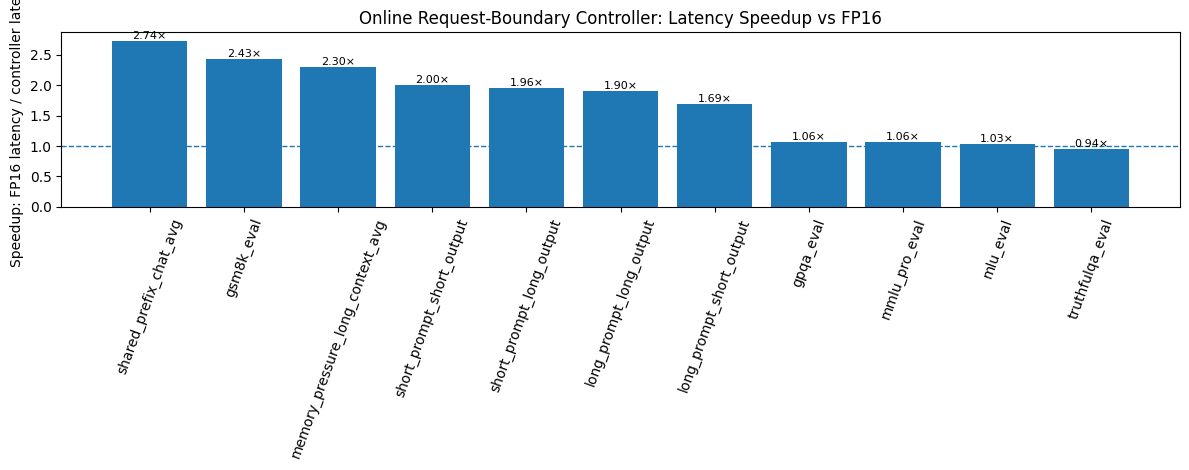

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/highlight_figure_pack/online_controller_energy_ratio_vs_fp16.png


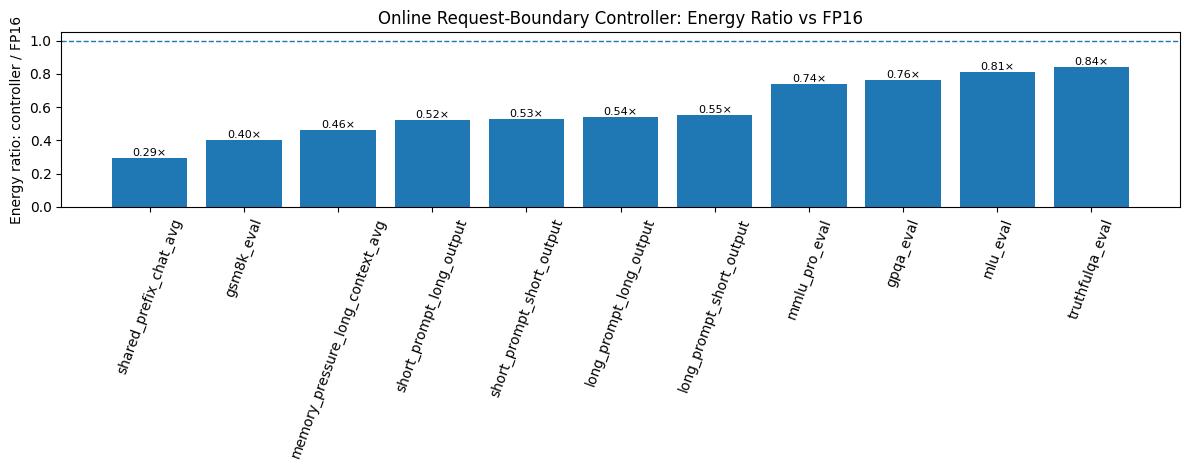

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/highlight_figure_pack/online_controller_accuracy_delta_vs_fp16.png


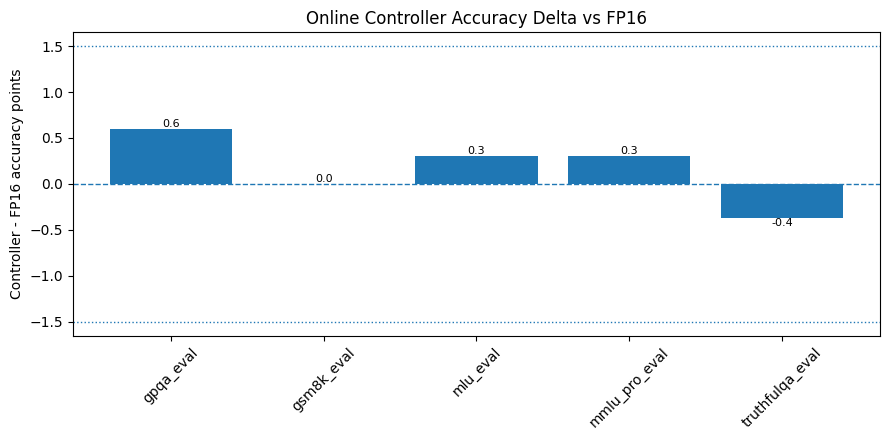

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/highlight_figure_pack/controller_mode_selection_counts.png


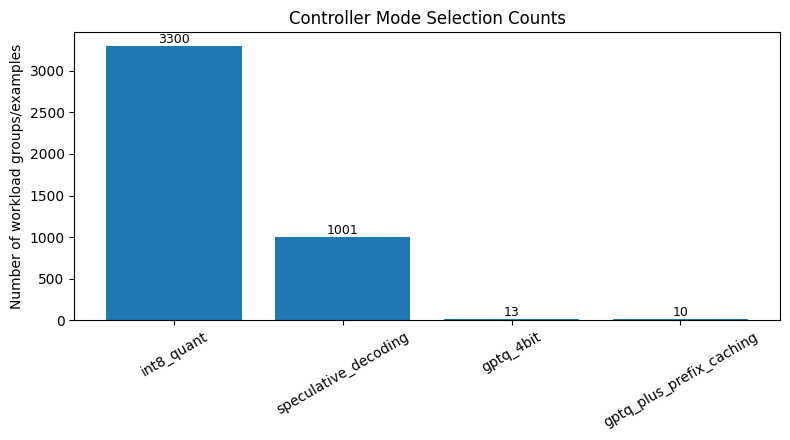

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/highlight_figure_pack/controller_oracle_gap.png


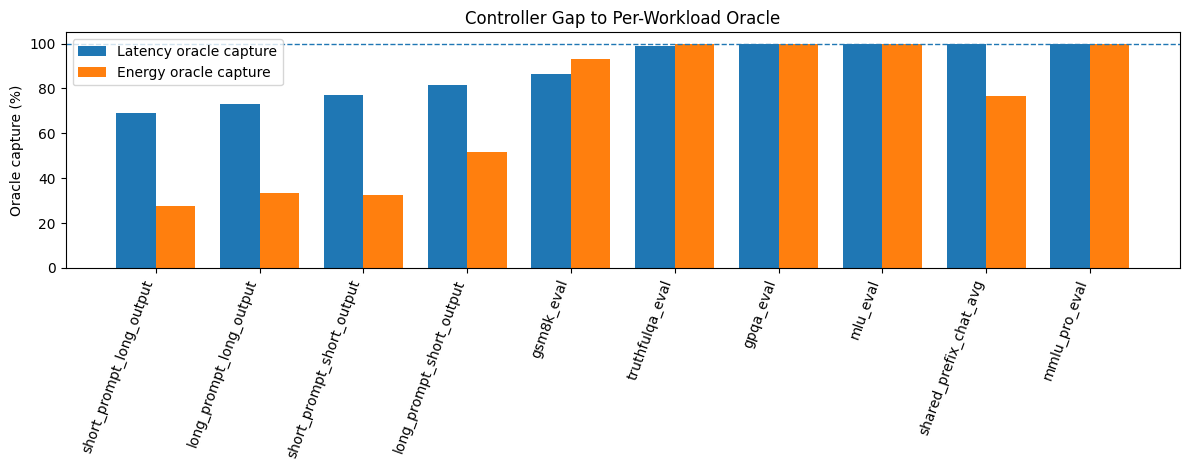

Highlight figure directory: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/highlight_figure_pack
Saved highlight figure index: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260506_024532/highlight_figure_pack/highlight_figure_index.csv


,figure_title,path,why_show,exists
0,Online controller latency speedup vs FP16,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Most direct result: shows end-to-end controlle...,True
1,Online controller energy ratio vs FP16,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Shows the strongest efficiency claim without i...,True
2,Online controller accuracy delta vs FP16,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Supports the claim that speed/energy gains did...,True
3,Controller mode selection counts,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Makes the routing policy interpretable by show...,True
4,Controller gap to per-workload oracle,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Important caveat figure: shows the controller ...,True
5,Fixed-mode latency speedup heatmap,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Shows which fixed modes dominate different wor...,True
6,Fixed-mode energy ratio heatmap,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Shows the strongest energy-efficiency patterns...,True
7,Automatic benchmark accuracy heatmap,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Shows benchmark quality across the 5 auto-grad...,True
8,Throughput heatmap,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Highlights the throughput advantage of continu...,True
9,Prefill share heatmap,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,Explains why some workloads favor prefix/prefi...,True


In [30]:
# ============================================================
# Cell 31: Highlight figure pack
# ============================================================

HIGHLIGHT_PLOT_DIR = PLOT_DIR / "highlight_figure_pack"
HIGHLIGHT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

highlight_figure_rows = []


def register_highlight_figure(path, title, why_show):
    """
    Track the most useful saved figures in one compact table.
    """
    highlight_figure_rows.append({
        "figure_title": title,
        "path": str(path),
        "why_show": why_show,
        "exists": Path(path).exists(),
    })


def save_current_highlight_figure(filename, title, why_show):
    """
    Save the current matplotlib figure and register it.
    """
    path = HIGHLIGHT_PLOT_DIR / filename
    plt.savefig(path, dpi=250, bbox_inches="tight")
    register_highlight_figure(path, title, why_show)
    print("Saved:", path)
    return path

def collapse_repeated_workload_name(workload_name):
    """
    Collapse repeated workload variants into one readable label.

    Example:
    shared_prefix_chat_v0, shared_prefix_chat_v1, ... -> shared_prefix_chat_avg
    memory_pressure_long_context_v0, ...             -> memory_pressure_long_context_avg
    """
    workload_name = str(workload_name)

    if workload_name.startswith("shared_prefix_chat"):
        return "shared_prefix_chat_avg"

    if workload_name.startswith("memory_pressure_long_context"):
        return "memory_pressure_long_context_avg"

    return workload_name


def average_repeated_workload_variants(df, sort_column, ascending=True):
    """
    Average repeated shared-prefix and memory-pressure variants before plotting.
    This keeps one bar per workload family instead of one bar per variant.
    """
    plot_df = df.copy()

    plot_df["_collapsed_workload_name"] = plot_df["workload_name"].apply(
        collapse_repeated_workload_name
    )

    numeric_cols = plot_df.select_dtypes(include=[np.number]).columns.tolist()

    grouped_df = (
        plot_df
        .groupby("_collapsed_workload_name", as_index=False)[numeric_cols]
        .mean()
    )

    grouped_df = grouped_df.rename(
        columns={"_collapsed_workload_name": "workload_name"}
    )

    grouped_df = grouped_df.sort_values(
        sort_column,
        ascending=ascending,
    ).reset_index(drop=True)

    return grouped_df


# ------------------------------------------------------------
# Figure 1: Online controller latency speedup vs FP16
# ------------------------------------------------------------

if "online_compare_df" in globals() and len(online_compare_df) > 0:
    plot_df = average_repeated_workload_variants(
        online_compare_df,
        sort_column="latency_speedup_with_routing",
        ascending=False,
    )

    fig, ax = plt.subplots(figsize=(12, 4.8))
    ax.bar(plot_df["workload_name"], plot_df["latency_speedup_with_routing"])
    ax.axhline(1.0, linestyle="--", linewidth=1)
    ax.set_title("Online Request-Boundary Controller: Latency Speedup vs FP16")
    ax.set_ylabel("Speedup: FP16 latency / controller latency")
    ax.tick_params(axis="x", rotation=70)

    for i, value in enumerate(plot_df["latency_speedup_with_routing"]):
        if pd.notna(value):
            ax.text(i, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    save_current_highlight_figure(
        filename="online_controller_latency_speedup_vs_fp16.png",
        title="Online controller latency speedup vs FP16",
        why_show="Most direct result: shows end-to-end controller speedup including routing overhead.",
    )
    plt.show()


# ------------------------------------------------------------
# Figure 2: Online controller energy ratio vs FP16
# ------------------------------------------------------------

if "online_compare_df" in globals() and len(online_compare_df) > 0:
    plot_df = average_repeated_workload_variants(
        online_compare_df,
        sort_column="energy_ratio",
        ascending=True,
    )

    fig, ax = plt.subplots(figsize=(12, 4.8))
    ax.bar(plot_df["workload_name"], plot_df["energy_ratio"])
    ax.axhline(1.0, linestyle="--", linewidth=1)
    ax.set_title("Online Request-Boundary Controller: Energy Ratio vs FP16")
    ax.set_ylabel("Energy ratio: controller / FP16")
    ax.tick_params(axis="x", rotation=70)

    for i, value in enumerate(plot_df["energy_ratio"]):
        if pd.notna(value):
            ax.text(i, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    save_current_highlight_figure(
        filename="online_controller_energy_ratio_vs_fp16.png",
        title="Online controller energy ratio vs FP16",
        why_show="Shows the strongest efficiency claim without implying memory savings.",
    )
    plt.show()


# ------------------------------------------------------------
# Figure 3: Online controller accuracy delta vs FP16
# ------------------------------------------------------------

if "online_controller_accuracy_df" in globals() and len(online_controller_accuracy_df) > 0:
    accuracy_plot_df = online_controller_accuracy_df.sort_values("workload_name").copy()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(accuracy_plot_df["workload_name"], accuracy_plot_df["delta_pts"])
    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.axhline(1.5, linestyle=":", linewidth=1)
    ax.axhline(-1.5, linestyle=":", linewidth=1)
    ax.set_title("Online Controller Accuracy Delta vs FP16")
    ax.set_ylabel("Controller - FP16 accuracy points")
    ax.tick_params(axis="x", rotation=45)

    for i, value in enumerate(accuracy_plot_df["delta_pts"]):
        if pd.notna(value):
            ax.text(
                i,
                value,
                f"{value:.1f}",
                ha="center",
                va="bottom" if value >= 0 else "top",
                fontsize=8,
            )

    plt.tight_layout()
    save_current_highlight_figure(
        filename="online_controller_accuracy_delta_vs_fp16.png",
        title="Online controller accuracy delta vs FP16",
        why_show="Supports the claim that speed/energy gains did not come with meaningful auto-graded quality loss.",
    )
    plt.show()


# ------------------------------------------------------------
# Figure 4: Controller selected-mode counts
# ------------------------------------------------------------

if "online_plan_df" in globals() and len(online_plan_df) > 0:
    mode_count_df = (
        online_plan_df["selected_mode_name"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="num_workloads")
    )
elif "controller_routing_df" in globals() and len(controller_routing_df) > 0:
    mode_count_df = (
        controller_routing_df["controller_selected_mode_name"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="num_workloads")
    )
else:
    mode_count_df = pd.DataFrame()

if len(mode_count_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(mode_count_df["selected_mode"], mode_count_df["num_workloads"])
    ax.set_title("Controller Mode Selection Counts")
    ax.set_ylabel("Number of workload groups/examples")
    ax.tick_params(axis="x", rotation=30)

    for i, value in enumerate(mode_count_df["num_workloads"]):
        ax.text(i, value, str(value), ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    save_current_highlight_figure(
        filename="controller_mode_selection_counts.png",
        title="Controller mode selection counts",
        why_show="Makes the routing policy interpretable by showing which modes the controller actually selected.",
    )
    plt.show()


# ------------------------------------------------------------
# Figure 5: Oracle gap for latency and energy
# ------------------------------------------------------------

if "controller_oracle_compare_df" in globals() and len(controller_oracle_compare_df) > 0:
    oracle_gap_df = average_repeated_workload_variants(
        controller_oracle_compare_df,
        sort_column="latency_oracle_over_controller",
        ascending=True,
    )
    oracle_gap_df["latency_capture_pct"] = 100.0 * oracle_gap_df["latency_oracle_over_controller"]
    oracle_gap_df["energy_capture_pct"] = 100.0 * oracle_gap_df["energy_oracle_over_controller"]
    oracle_gap_df = oracle_gap_df.sort_values("latency_capture_pct", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 4.8))
    x = np.arange(len(oracle_gap_df))
    width = 0.38

    ax.bar(x - width / 2, oracle_gap_df["latency_capture_pct"], width, label="Latency oracle capture")
    ax.bar(x + width / 2, oracle_gap_df["energy_capture_pct"], width, label="Energy oracle capture")
    ax.axhline(100.0, linestyle="--", linewidth=1)
    ax.set_title("Controller Gap to Per-Workload Oracle")
    ax.set_ylabel("Oracle capture (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(oracle_gap_df["workload_name"], rotation=70, ha="right")
    ax.legend()

    plt.tight_layout()
    save_current_highlight_figure(
        filename="controller_oracle_gap.png",
        title="Controller gap to per-workload oracle",
        why_show="Important caveat figure: shows the controller is strong but not oracle-optimal.",
    )
    plt.show()


# ------------------------------------------------------------
# Register already-saved heatmaps from earlier cells
# ------------------------------------------------------------

existing_highlight_candidates = [
    (
        PLOT_DIR / "latency_speedup_vs_baseline_heatmap.png",
        "Fixed-mode latency speedup heatmap",
        "Shows which fixed modes dominate different workload families.",
    ),
    (
        PLOT_DIR / "energy_ratio_vs_baseline_heatmap.png",
        "Fixed-mode energy ratio heatmap",
        "Shows the strongest energy-efficiency patterns across modes.",
    ),
    (
        PLOT_DIR / "automatic_accuracy_heatmap.png",
        "Automatic benchmark accuracy heatmap",
        "Shows benchmark quality across the 5 auto-graded benchmarks.",
    ),
    (
        PLOT_DIR / "throughput_heatmap.png",
        "Throughput heatmap",
        "Highlights the throughput advantage of continuous batching and INT8-related modes.",
    ),
    (
        PLOT_DIR / "prefill_share_heatmap.png",
        "Prefill share heatmap",
        "Explains why some workloads favor prefix/prefill-oriented modes.",
    ),
    (
        PLOT_DIR / "decode_share_heatmap.png",
        "Decode share heatmap",
        "Explains why long-generation workloads favor decode-oriented modes.",
    ),
    (
        PLOT_DIR / "peak_gpu_memory_heatmap.png",
        "Peak GPU memory heatmap",
        "Useful as a caveat: memory is basically unchanged, so do not claim memory savings.",
    ),
]

for path, title, why_show in existing_highlight_candidates:
    register_highlight_figure(path, title, why_show)


# ------------------------------------------------------------
# Final compact table of recommended figures
# ------------------------------------------------------------

highlight_figure_df = pd.DataFrame(highlight_figure_rows)
highlight_figure_df = highlight_figure_df.drop_duplicates(subset=["path"]).reset_index(drop=True)

highlight_table_path = HIGHLIGHT_PLOT_DIR / "highlight_figure_index.csv"
highlight_figure_df.to_csv(highlight_table_path, index=False)

print("Highlight figure directory:", HIGHLIGHT_PLOT_DIR)
print("Saved highlight figure index:", highlight_table_path)
display(highlight_figure_df)

In [ ]:
# ============================================================
# Cell 27B: Final summary tables for ONLINE controller
# ============================================================

ONLINE_FINAL_TABLE_DIR = TABLE_DIR / "final_paper_tables_online_controller"
ONLINE_FINAL_TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Helper: collapse repeated workload variants before averaging
# ------------------------------------------------------------

def collapse_repeated_workload_name_for_tables(workload_name):
    """
    Collapse synthetic repeated variants so shared-prefix/memory-pressure
    workloads do not dominate the reported averages.
    """
    workload_name = str(workload_name)

    if workload_name.startswith("shared_prefix_chat"):
        return "shared_prefix_chat_avg"

    if workload_name.startswith("memory_pressure_long_context"):
        return "memory_pressure_long_context_avg"

    return workload_name


def collapse_online_compare_for_summary(df):
    """
    Average numeric metrics across repeated workload variants.
    Keeps one row per logical workload family.
    """
    collapsed_df = df.copy()

    collapsed_df["collapsed_workload_name"] = collapsed_df["workload_name"].apply(
        collapse_repeated_workload_name_for_tables
    )

    numeric_cols = collapsed_df.select_dtypes(include=[np.number]).columns.tolist()

    collapsed_df = (
        collapsed_df
        .groupby("collapsed_workload_name", as_index=False)[numeric_cols]
        .mean()
        .rename(columns={"collapsed_workload_name": "workload_name"})
    )

    return collapsed_df


def safe_mean(df, col):
    """
    Return mean if the column exists; otherwise return NaN.
    """
    if df is not None and col in df.columns:
        return df[col].mean()
    return np.nan


# ------------------------------------------------------------
# Build collapsed online-controller performance table
# ------------------------------------------------------------

if "online_compare_df" not in globals() or len(online_compare_df) == 0:
    raise RuntimeError("online_compare_df is missing or empty. Run the online controller comparison cell first.")

online_compare_summary_df = collapse_online_compare_for_summary(online_compare_df)

online_compare_summary_df = online_compare_summary_df.sort_values(
    "latency_speedup_with_routing",
    ascending=False,
).reset_index(drop=True)


# ------------------------------------------------------------
# Online controller quality gate
# ------------------------------------------------------------

if "online_controller_accuracy_df" in globals() and len(online_controller_accuracy_df) > 0:
    online_accuracy_summary_df = online_controller_accuracy_df.copy()

    if "workload_name" in online_accuracy_summary_df.columns:
        online_accuracy_summary_df["workload_name"] = online_accuracy_summary_df["workload_name"].apply(
            collapse_repeated_workload_name_for_tables
        )

    numeric_cols = online_accuracy_summary_df.select_dtypes(include=[np.number]).columns.tolist()

    online_accuracy_summary_df = (
        online_accuracy_summary_df
        .groupby("workload_name", as_index=False)[numeric_cols]
        .mean()
    )

    online_mean_accuracy_delta_pts = safe_mean(online_accuracy_summary_df, "delta_pts")

    if "delta_pts" in online_accuracy_summary_df.columns:
        online_controller_quality_pass = bool(
            online_accuracy_summary_df["delta_pts"].abs().max() <= 1.5
        )
    else:
        online_controller_quality_pass = False
else:
    online_accuracy_summary_df = pd.DataFrame()
    online_mean_accuracy_delta_pts = np.nan
    online_controller_quality_pass = False


# ------------------------------------------------------------
# Online controller selected-mode counts
# ------------------------------------------------------------

if "online_plan_df" in globals() and len(online_plan_df) > 0 and "selected_mode_name" in online_plan_df.columns:
    online_mode_count_df = (
        online_plan_df["selected_mode_name"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="num_online_routes")
    )
elif "controller_routing_df" in globals() and len(controller_routing_df) > 0 and "controller_selected_mode_name" in controller_routing_df.columns:
    online_mode_count_df = (
        controller_routing_df["controller_selected_mode_name"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="num_online_routes")
    )
else:
    online_mode_count_df = pd.DataFrame()


# ------------------------------------------------------------
# Headline machine-readable summary
# ------------------------------------------------------------

online_headline_summary_df = pd.DataFrame([{
    "controller_evaluation_type": "online_request_boundary_routing_with_measured_routing_overhead",
    "averaging_policy": "repeated shared-prefix and memory-pressure variants collapsed before averaging",
    "num_logical_workloads": len(online_compare_summary_df),
    "mean_controller_total_latency_with_routing_ms": safe_mean(
        online_compare_summary_df,
        "controller_total_latency_with_routing_ms_mean",
    ),
    "mean_fp16_total_latency_ms": safe_mean(
        online_compare_summary_df,
        "fp16_total_latency_ms_mean",
    ),
    "mean_routing_overhead_ms": safe_mean(
        online_compare_summary_df,
        "controller_routing_overhead_ms_mean",
    ),
    "mean_latency_speedup_with_routing": safe_mean(
        online_compare_summary_df,
        "latency_speedup_with_routing",
    ),
    "mean_throughput_ratio": safe_mean(
        online_compare_summary_df,
        "throughput_ratio",
    ),
    "mean_energy_ratio": safe_mean(
        online_compare_summary_df,
        "energy_ratio",
    ),
    "mean_energy_reduction_pct": 100.0 * (
        1.0 - safe_mean(online_compare_summary_df, "energy_ratio")
    ),
    "mean_memory_ratio": safe_mean(
        online_compare_summary_df,
        "memory_ratio",
    ),
    "mean_accuracy_delta_pts": online_mean_accuracy_delta_pts,
    "quality_threshold_pass": "PASS" if online_controller_quality_pass else "FAIL_OR_NOT_AVAILABLE",
    "quality_scope": "auto-graded benchmarks only",
    "external_judge_quality_included": RUN_EXTERNAL_JUDGE_WORKLOADS if "RUN_EXTERNAL_JUDGE_WORKLOADS" in globals() else False,
    "latency_claim": "Latency includes online routing overhead",
    "memory_claim": "No meaningful GPU memory reduction claimed",
    "oracle_claim": "Online controller is not oracle-optimal; oracle gap should be reported separately if available",
    "cache_caveat": (
        "Synthetic repeated trials may favor prefix-caching modes unless unique "
        "trial headers are enabled for future reruns."
    ),
}])


# ------------------------------------------------------------
# Human-readable paper table
# ------------------------------------------------------------

online_paper_summary_display = pd.DataFrame([
    {
        "Metric": "Controller evaluation type",
        "Value": "Online request-boundary routing with measured routing overhead",
    },
    {
        "Metric": "Averaging policy",
        "Value": "Repeated shared-prefix and memory-pressure variants collapsed before averaging",
    },
    {
        "Metric": "Logical workloads summarized",
        "Value": str(online_headline_summary_df.iloc[0]["num_logical_workloads"]),
    },
    {
        "Metric": "Mean latency speedup vs FP16",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_latency_speedup_with_routing']:.2f}×",
    },
    {
        "Metric": "Mean controller latency including routing",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_controller_total_latency_with_routing_ms']:.2f} ms",
    },
    {
        "Metric": "Mean FP16 latency",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_fp16_total_latency_ms']:.2f} ms",
    },
    {
        "Metric": "Mean routing overhead",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_routing_overhead_ms']:.4f} ms",
    },
    {
        "Metric": "Mean throughput ratio vs FP16",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_throughput_ratio']:.2f}×",
    },
    {
        "Metric": "Mean energy ratio vs FP16",
        "Value": (
            f"{online_headline_summary_df.iloc[0]['mean_energy_ratio']:.2f}× "
            f"({online_headline_summary_df.iloc[0]['mean_energy_reduction_pct']:.1f}% lower)"
        ),
    },
    {
        "Metric": "Mean GPU memory ratio vs FP16",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_memory_ratio']:.3f}×",
    },
    {
        "Metric": "Mean accuracy delta",
        "Value": (
            f"{online_headline_summary_df.iloc[0]['mean_accuracy_delta_pts']:.2f} points"
            if pd.notna(online_headline_summary_df.iloc[0]["mean_accuracy_delta_pts"])
            else "Not available"
        ),
    },
    {
        "Metric": "Quality threshold",
        "Value": online_headline_summary_df.iloc[0]["quality_threshold_pass"],
    },
    {
        "Metric": "Quality scope",
        "Value": "Auto-graded benchmarks only; external judge workloads excluded unless explicitly enabled",
    },
    {
        "Metric": "Main caveat",
        "Value": "Controller includes routing overhead, but it is still not oracle-optimal",
    },
])


# ------------------------------------------------------------
# Save online paper tables
# ------------------------------------------------------------

online_headline_summary_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_headline_summary.csv",
    index=False,
)

online_paper_summary_display.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_paper_headline_table.csv",
    index=False,
)

online_paper_summary_display.to_latex(
    ONLINE_FINAL_TABLE_DIR / "online_paper_headline_table.tex",
    index=False,
    escape=False,
)

online_compare_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_controller_vs_fp16_performance_raw.csv",
    index=False,
)

online_compare_summary_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_controller_vs_fp16_performance_collapsed.csv",
    index=False,
)

online_accuracy_summary_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_controller_accuracy_gate.csv",
    index=False,
)

online_mode_count_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_controller_mode_counts.csv",
    index=False,
)


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("Online controller final paper summary:")
display(online_paper_summary_display)

print("Collapsed online controller performance table:")
display(online_compare_summary_df)

if len(online_mode_count_df) > 0:
    print("Online controller selected-mode counts:")
    display(online_mode_count_df)

print("Saved online final paper tables to:", ONLINE_FINAL_TABLE_DIR)
for path in sorted(ONLINE_FINAL_TABLE_DIR.glob("*")):
    print(" -", path)

Online controller final paper summary:


,Metric,Value
0,Controller evaluation type,Online request-boundary routing with measured ...
1,Averaging policy,Repeated shared-prefix and memory-pressure var...
2,Logical workloads summarized,11
3,Mean latency speedup vs FP16,1.74×
4,Mean controller latency including routing,613.53 ms
5,Mean FP16 latency,1295.80 ms
6,Mean routing overhead,0.0000 ms
7,Mean throughput ratio vs FP16,1.74×
8,Mean energy ratio vs FP16,0.59× (41.3% lower)
9,Mean GPU memory ratio vs FP16,1.007×


Collapsed online controller performance table:


,workload_name,n,failure_count,failure_rate,num_requests_in_batch_mean,prompt_tokens_target_mean,max_new_tokens_mean,ttft_ms_mean,ttft_ms_std,ttft_ms_median,...,fp16_total_latency_ms_mean,fp16_tokens_per_second_mean,fp16_energy_per_token_j_mean,fp16_peak_gpu_memory_mb_mean,controller_routing_overhead_ms_mean,controller_total_latency_with_routing_ms_mean,latency_speedup_with_routing,throughput_ratio,energy_ratio,memory_ratio
0,shared_prefix_chat_avg,30.0,0.0,0.0,1.0,1024.0,64.0,35.426735,NaN,NaN,...,1397.337528,45.811351,4.910410,32807.771289,0.0,510.756123,2.735846,2.736634,0.294243,1.007574
1,gsm8k_eval,1000.0,0.0,0.0,1.0,512.0,384.0,36.325904,NaN,NaN,...,3097.149247,49.897420,4.007192,32669.518399,0.0,1274.175268,2.430709,2.451578,0.403046,1.006329
2,memory_pressure_long_context_avg,30.0,0.0,0.0,1.0,2048.0,128.0,212.078510,NaN,NaN,...,2708.885952,47.256521,4.549812,36826.921240,0.0,1179.321979,2.296999,2.296986,0.464864,1.006636
3,short_prompt_short_output,30.0,0.0,0.0,1.0,128.0,32.0,37.950967,NaN,NaN,...,686.973315,46.592083,3.862559,32669.332520,0.0,343.646821,1.999068,2.003811,0.528802,1.009575
4,short_prompt_long_output,30.0,0.0,0.0,1.0,128.0,128.0,38.076694,NaN,NaN,...,2682.208007,47.726585,4.009347,32672.323145,0.0,1366.222564,1.963229,1.963102,0.520503,1.009483
5,long_prompt_long_output,30.0,0.0,0.0,1.0,1024.0,128.0,127.368445,NaN,NaN,...,2727.091607,46.940042,4.345715,32814.924316,0.0,1432.999503,1.903065,1.914282,0.540608,1.009284
6,long_prompt_short_output,30.0,0.0,0.0,1.0,1024.0,32.0,88.379790,NaN,NaN,...,751.536719,42.582641,5.055007,32814.924316,0.0,443.841363,1.693255,1.693317,0.551613,1.006263
7,gpqa_eval,500.0,0.0,0.0,1.0,512.0,8.0,39.289815,NaN,NaN,...,53.611072,19.048634,9.711266,32686.642629,0.0,50.589815,1.059721,1.043481,0.762398,1.006294
8,mmlu_pro_eval,1000.0,0.0,0.0,1.0,512.0,8.0,38.634520,NaN,NaN,...,52.887388,19.530367,8.410643,32686.119033,0.0,49.940471,1.059009,1.044950,0.741413,1.006668
9,mlu_eval,1000.0,0.0,0.0,1.0,512.0,8.0,38.425547,NaN,NaN,...,51.108888,20.099523,8.099489,32682.020282,0.0,49.609342,1.030227,1.010757,0.810036,1.006667


Online controller selected-mode counts:


,selected_mode,num_online_routes
0,int8_quant,3300
1,speculative_decoding,1001
2,gptq_4bit,13
3,gptq_plus_prefix_caching,10


Saved online final paper tables to: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables_online_controller
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables_online_controller/online_controller_accuracy_gate.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables_online_controller/online_controller_mode_counts.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables_online_controller/online_controller_vs_fp16_performance_collapsed.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024532/final_paper_tables_online_controller/online_controller_vs_fp16_performance_raw.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260506_024

In [32]:
# ============================================================
# Better controller mode-selection figures
# ============================================================

import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# Pick the controller dataframe.
# Change this line if your dataframe has a different name.
# It must contain at least:
#   workload_name
#   controller_selected_mode_name
# ------------------------------------------------------------

controller_df = online_controller_df.copy()  # <-- change if needed

PLOT_DIR = Path("results/plots/controller_selection")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def base_workload_name(name):
    """
    Collapse sidecar-expanded and synthetic-variant workload names.

    Examples:
    mmlu_pro_eval__q0001 -> mmlu_pro_eval
    shared_prefix_chat_v17 -> shared_prefix_chat
    memory_pressure_long_context_v03 -> memory_pressure_long_context
    """
    name = str(name)

    if "__" in name:
        name = name.split("__", 1)[0]

    name = re.sub(r"_v\d+$", "", name)

    return name


def infer_workload_group(row):
    """
    Give each row a clean project-level group label.
    """
    workload = row["base_workload_name"]

    synthetic_workloads = {
        "short_prompt_short_output",
        "short_prompt_long_output",
        "long_prompt_short_output",
        "long_prompt_long_output",
        "shared_prefix_chat",
        "memory_pressure_long_context",
    }

    if workload in synthetic_workloads:
        return "synthetic"

    return "benchmark"


def infer_benchmark_group(row):
    """
    Prefer benchmark_suite if available; otherwise infer from workload name.
    """
    if "benchmark_suite" in row and pd.notna(row["benchmark_suite"]):
        return str(row["benchmark_suite"])

    workload = row["base_workload_name"]

    mapping = {
        "mmlu_pro_eval": "mmlu_pro",
        "gsm8k_eval": "gsm8k",
        "truthfulqa_eval": "truthfulqa",
        "gpqa_eval": "gpqa",
        "mlu_eval": "mlu",
        "mt_bench_eval": "mt_bench",
        "alpacaeval2_lc_eval": "alpacaeval2_lc",
    }

    return mapping.get(workload, workload)


# ------------------------------------------------------------
# Clean controller table
# ------------------------------------------------------------

plot_df = controller_df.copy()

plot_df["selected_mode"] = plot_df["controller_selected_mode_name"].fillna(
    plot_df.get("mode_name", "unknown")
)

plot_df["base_workload_name"] = plot_df["workload_name"].apply(base_workload_name)
plot_df["workload_group"] = plot_df.apply(infer_workload_group, axis=1)
plot_df["benchmark_group"] = plot_df.apply(infer_benchmark_group, axis=1)

display(plot_df[[
    "workload_name",
    "base_workload_name",
    "workload_group",
    "benchmark_group",
    "selected_mode",
]].head())


# ------------------------------------------------------------
# Helper plotting function
# ------------------------------------------------------------

def save_bar_plot(series, title, ylabel, filename, rotation=35):
    ax = series.plot(kind="bar", figsize=(10, 4))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=rotation)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3)

    plt.tight_layout()
    path = PLOT_DIR / filename
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def save_stacked_bar_plot(table, title, ylabel, filename, rotation=35):
    ax = table.plot(kind="bar", stacked=True, figsize=(11, 4))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=rotation)
    ax.legend(title="Selected mode", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    path = PLOT_DIR / filename
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# ============================================================
# Figure 1: Mode selection by workload family
# ============================================================

family_table = pd.crosstab(
    plot_df["base_workload_name"],
    plot_df["selected_mode"],
)

save_stacked_bar_plot(
    family_table,
    "Controller Mode Selection by Workload Family",
    "Number of rows/examples",
    "mode_selection_by_workload_family.png",
    rotation=45,
)


# ============================================================
# Figure 2: Mode selection by benchmark group
# ============================================================

benchmark_df = plot_df[plot_df["workload_group"] == "benchmark"].copy()

benchmark_table = pd.crosstab(
    benchmark_df["benchmark_group"],
    benchmark_df["selected_mode"],
)

save_stacked_bar_plot(
    benchmark_table,
    "Controller Mode Selection by Benchmark Group",
    "Number of benchmark examples",
    "mode_selection_by_benchmark_group.png",
    rotation=35,
)


# ============================================================
# Figure 3: Weighted mode selection
# One workload family = one vote
# ============================================================

weighted_rows = []

for family, group in plot_df.groupby("base_workload_name"):
    selected_mode = group["selected_mode"].mode().iloc[0]
    weighted_rows.append({
        "base_workload_name": family,
        "selected_mode": selected_mode,
        "raw_rows": len(group),
    })

weighted_df = pd.DataFrame(weighted_rows)

weighted_counts = weighted_df["selected_mode"].value_counts()

save_bar_plot(
    weighted_counts,
    "Weighted Controller Mode Selection",
    "Number of workload families",
    "weighted_mode_selection_one_vote_per_family.png",
    rotation=30,
)

display(weighted_df.sort_values("base_workload_name"))


# ============================================================
# Figure 4: Separate synthetic vs benchmark routing
# ============================================================

group_table = pd.crosstab(
    plot_df["workload_group"],
    plot_df["selected_mode"],
)

save_stacked_bar_plot(
    group_table,
    "Controller Mode Selection: Synthetic vs Benchmark Workloads",
    "Number of rows/examples",
    "mode_selection_synthetic_vs_benchmark.png",
    rotation=0,
)

NameError: name 'online_controller_df' is not defined